In [2]:
# Imports & global config

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "../data/oulad"   


In [3]:
# Load raw OULAD data

student_info = pd.read_csv(os.path.join(DATA_DIR, "studentInfo.csv"))
student_vle = pd.read_csv(os.path.join(DATA_DIR, "studentVle.csv"))
student_assessment = pd.read_csv(os.path.join(DATA_DIR, "studentAssessment.csv"))
student_reg = pd.read_csv(os.path.join(DATA_DIR, "studentRegistration.csv"))
assessments = pd.read_csv(os.path.join(DATA_DIR, "assessments.csv"))

print("student_info:", student_info.shape)
print("student_vle:", student_vle.shape)
print("student_assessment:", student_assessment.shape)
print("student_reg:", student_reg.shape)
print("assessments:", assessments.shape)

student_info.head()


student_info: (32593, 12)
student_vle: (10655280, 6)
student_assessment: (173912, 5)
student_reg: (32593, 5)
assessments: (206, 6)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
student_info["final_result"].value_counts(normalize=True) * 100


final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64

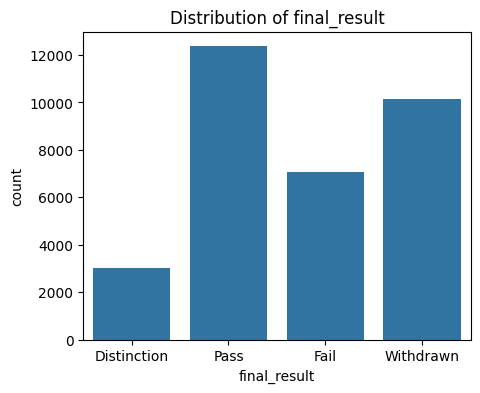

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(data=student_info, x="final_result",
              order=["Distinction","Pass","Fail","Withdrawn"])
plt.title("Distribution of final_result")
plt.show()


In [4]:
# Behavioural features from studentVle

# total clicks per student
vle_agg = (
    student_vle
    .groupby("id_student")
    .agg(
        total_clicks=("sum_click", "sum"),
        days_active=("date", "nunique"),
        max_daily_clicks=("sum_click", "max"),
        mean_daily_clicks=("sum_click", "mean")
    )
    .reset_index()
)

# Early engagement: clicks in first 30 days
early_vle = (
    student_vle[student_vle["date"] <= 30]
    .groupby("id_student")
    .agg(early_clicks=("sum_click", "sum"))
    .reset_index()
)

vle_agg = vle_agg.merge(early_vle, on="id_student", how="left")
vle_agg["early_clicks"] = vle_agg["early_clicks"].fillna(0)

vle_agg.head()


,id_student,total_clicks,days_active,max_daily_clicks,mean_daily_clicks,early_clicks
0,6516,2791,159,49,4.216012,834.0
1,8462,656,56,16,2.157895,419.0
2,11391,934,40,76,4.765306,424.0
3,23629,161,16,13,2.728814,53.0
4,23698,910,70,78,2.983607,369.0


In [5]:
# Performance features from studentAssessment

# Convert score to numeric, handling any non-numeric values
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')

ass_agg = (
    student_assessment
    .groupby("id_student")
    .agg(
        mean_score=("score", "mean"),
        num_assessments=("id_assessment", "count")
    )
    .reset_index()
)

ass_agg["mean_score"] = ass_agg["mean_score"].fillna(0)
ass_agg.head()


,id_student,mean_score,num_assessments
0,6516,61.800000,5
1,8462,87.000000,7
2,11391,82.000000,5
3,23629,82.500000,4
4,23698,74.444444,9


In [6]:
# Features from studentRegistration

reg_agg = student_reg.copy()

reg_agg["unregistered"] = reg_agg["date_unregistration"].notna().astype(int)

# Convert date_registration to numeric first
reg_agg["date_registration"] = pd.to_numeric(reg_agg["date_registration"], errors='coerce')
reg_agg["reg_before_start"] = -reg_agg["date_registration"]  # days before start; negative means after

reg_agg = reg_agg.groupby("id_student").agg(
    first_reg_before_start=("reg_before_start","max"),
    ever_unregistered=("unregistered","max")
).reset_index()

reg_agg.head()


,id_student,first_reg_before_start,ever_unregistered
0,3733,68.0,1
1,6516,52.0,1
2,8462,137.0,1
3,11391,159.0,1
4,23629,47.0,1


In [7]:
# Merge everything by id_student

data = (
    student_info
    .merge(vle_agg, on="id_student", how="left")
    .merge(ass_agg, on="id_student", how="left")
    .merge(reg_agg, on="id_student", how="left")
)

# Replace NaNs from missing behavior / assessments with 0
behavior_cols = ["total_clicks","days_active","max_daily_clicks",
                 "mean_daily_clicks","early_clicks","mean_score",
                 "num_assessments","first_reg_before_start","ever_unregistered"]

for c in behavior_cols:
    data[c] = data[c].fillna(0)

print(data.shape)
data.head()


(32593, 21)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,total_clicks,days_active,max_daily_clicks,mean_daily_clicks,early_clicks,mean_score,num_assessments,first_reg_before_start,ever_unregistered
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,Pass,934.0,40.0,76.0,4.765306,424.0,82.0,5.0,159.0,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,Pass,1435.0,80.0,23.0,3.337209,618.0,66.4,5.0,53.0,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,Withdrawn,281.0,12.0,23.0,3.697368,281.0,0.0,0.0,92.0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,Pass,2158.0,123.0,22.0,3.254902,540.0,76.0,5.0,52.0,1
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,Pass,1034.0,70.0,22.0,2.937500,567.0,54.4,5.0,176.0,1


In [8]:
# Drop rows without final_result 

data = data[~data["final_result"].isna()].copy()

#4-class target
target_col = "final_result"
data[target_col].value_counts()


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [9]:
# feature list

categorical_features = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module",
    "code_presentation",
]

numeric_features = behavior_cols + [
    "num_of_prev_attempts",
    "studied_credits",
]

X = data[categorical_features + numeric_features]
y = data[target_col]   # 'final_result' (4 classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((26074, 19), (6519, 19))

In [10]:
# Preprocessing and PCA

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

# create a pipeline that first preprocesses, then reduces dimensionality, then classifies.
pca = PCA(n_components=20, random_state=RANDOM_STATE)
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

from sklearn.pipeline import Pipeline

clf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", pca),                 
    ("clf", rf_clf)
])

clf_pipeline


,steps,"[('preprocess', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#Train model

clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

 Distinction       0.62      0.10      0.17       605
        Fail       0.57      0.35      0.43      1411
        Pass       0.66      0.93      0.77      2472
   Withdrawn       0.72      0.73      0.73      2031

    accuracy                           0.67      6519
   macro avg       0.64      0.53      0.53      6519
weighted avg       0.66      0.67      0.63      6519



In [ ]:
# Fit a pipeline *without* classifier to get embeddings

embed_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", pca)
])

embeddings = embed_pipeline.fit_transform(X)   # full dataset
embeddings.shape


(32593, 20)

In [ ]:
# KMeans clustering in embedding space

N_CLUSTERS = 4  

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10
)
cluster_labels = kmeans.fit_predict(embeddings)

data["cluster"] = cluster_labels
data["cluster"].value_counts()


cluster
2    16963
0     6436
3     6103
1     3091
Name: count, dtype: int64

In [19]:
cluster_summary = (
    data
    .groupby("cluster")
    .agg(
        avg_total_clicks=("total_clicks","mean"),
        avg_days_active=("days_active","mean"),
        avg_mean_score=("mean_score","mean"),
        pass_rate=("final_result", lambda s: np.mean(s.isin(["Pass","Distinction"]))),
        fail_or_withdraw_rate=("final_result", lambda s: np.mean(s.isin(["Fail","Withdrawn"])))
    )
    .sort_values("avg_total_clicks", ascending=False)
)

cluster_summary


,avg_total_clicks,avg_days_active,avg_mean_score,pass_rate,fail_or_withdraw_rate
cluster,,,,,
3,4689.583811,151.868589,79.419763,0.810093,0.189907
2,963.777398,56.308141,72.838417,0.551671,0.448329
1,908.510514,51.302815,64.343352,0.346813,0.653187
0,66.632070,4.580951,4.246854,0.001709,0.998291


In [ ]:
# Example mapping


cluster_to_profile = {
    0: "Fast learners",
    1: "Balanced learners",
    2: "Struggling learners",
    3: "Disengaged learners"
}

data["learner_profile"] = data["cluster"].map(cluster_to_profile)

data[["id_student","final_result","learner_profile"]].head()


,id_student,final_result,learner_profile
0,11391,Pass,Struggling learners
1,28400,Pass,Struggling learners
2,30268,Withdrawn,Fast learners
3,31604,Pass,Struggling learners
4,32885,Pass,Struggling learners


In [21]:
data["learner_profile"].value_counts(normalize=True) * 100


learner_profile
Struggling learners    52.044918
Fast learners          19.746571
Disengaged learners    18.724880
Balanced learners       9.483631
Name: proportion, dtype: float64

In [25]:
# Supervised classifier with learnerprofile as target

profile_data = data.dropna(subset=["learner_profile"]).copy()

Xp = profile_data[categorical_features + numeric_features]
yp = profile_data["learner_profile"]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.2, stratify=yp, random_state=RANDOM_STATE
)

profile_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", PCA(n_components=20, random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

profile_clf.fit(Xp_train, yp_train)
yp_pred = profile_clf.predict(Xp_test)

print(classification_report(yp_test, yp_pred))


                     precision    recall  f1-score   support

  Balanced learners       1.00      0.99      1.00       618
Disengaged learners       0.98      0.97      0.98      1221
      Fast learners       0.99      0.97      0.98      1287
Struggling learners       0.98      0.99      0.99      3393

           accuracy                           0.98      6519
          macro avg       0.99      0.98      0.98      6519
       weighted avg       0.98      0.98      0.98      6519



In [23]:
ARTIFACT_DIR = "./artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(clf_pipeline, os.path.join(ARTIFACT_DIR, "final_result_classifier.joblib"))
joblib.dump(embed_pipeline, os.path.join(ARTIFACT_DIR, "embedding_pipeline.joblib"))
joblib.dump(kmeans, os.path.join(ARTIFACT_DIR, "kmeans_profiles.joblib"))
joblib.dump(profile_clf, os.path.join(ARTIFACT_DIR, "profile_classifier.joblib"))

print("Artifacts saved in", ARTIFACT_DIR)


Artifacts saved in ./artifacts


In [ ]:
# Example inference

new_student = pd.DataFrame([{
    "gender": "M",
    "region": "East Anglian Region",
    "highest_education": "A Level or Equivalent",
    "imd_band": "20-30",
    "age_band": "26-35",
    "disability": "N",
    "code_module": "AAA",
    "code_presentation": "2013B",
    "num_of_prev_attempts": 0,
    "studied_credits": 60,
    "total_clicks": 300,
    "days_active": 15,
    "max_daily_clicks": 60,
    "mean_daily_clicks": 20,
    "early_clicks": 150,
    "mean_score": 75,
    "num_assessments": 3,
    "first_reg_before_start": 30,
    "ever_unregistered": 0,
}])

# Load artifacts (simulating a production scenario)
final_result_model = joblib.load(os.path.join(ARTIFACT_DIR, "final_result_classifier.joblib"))
profile_model = joblib.load(os.path.join(ARTIFACT_DIR, "profile_classifier.joblib"))

pred_result = final_result_model.predict(new_student)[0]
pred_profile = profile_model.predict(new_student)[0]

print("Predicted final_result:", pred_result)
print("Predicted learner_profile:", pred_profile)


Predicted final_result: Withdrawn
Predicted learner_profile: Disengaged learners


In [ ]:
import joblib
import pandas as pd
import numpy as np

ARTIFACT_DIR = "./artifacts"  

# load models
final_result_model = joblib.load(f"{ARTIFACT_DIR}/final_result_classifier.joblib")
profile_model = joblib.load(f"{ARTIFACT_DIR}/profile_classifier.joblib")
embed_pipeline = joblib.load(f"{ARTIFACT_DIR}/embedding_pipeline.joblib")
kmeans = joblib.load(f"{ARTIFACT_DIR}/kmeans_profiles.joblib")


# e.g. new_student = pd.DataFrame([...])  

# 1. Predicted classes
pred_result = final_result_model.predict(new_student)[0]
pred_profile = profile_model.predict(new_student)[0]
print("Predicted final_result:", pred_result)
print("Predicted learner_profile:", pred_profile)

# 2. Probabilities — how confident?
if hasattr(final_result_model, "predict_proba"):
    probs = final_result_model.predict_proba(new_student)[0]
    classes = final_result_model.named_steps["clf"].classes_ if hasattr(final_result_model, "named_steps") else final_result_model.classes_
    print("final_result class probs:")
    print(dict(zip(classes, np.round(probs,3))))

if hasattr(profile_model, "predict_proba"):
    p_probs = profile_model.predict_proba(new_student)[0]
    p_classes = profile_model.named_steps["clf"].classes_ if hasattr(profile_model, "named_steps") else profile_model.classes_
    print("profile class probs:")
    print(dict(zip(p_classes, np.round(p_probs,3))))


Predicted final_result: Withdrawn
Predicted learner_profile: Disengaged learners
final_result class probs:
{'Distinction': np.float64(0.077), 'Fail': np.float64(0.31), 'Pass': np.float64(0.3), 'Withdrawn': np.float64(0.313)}
profile class probs:
{'Balanced learners': np.float64(0.073), 'Disengaged learners': np.float64(0.487), 'Fast learners': np.float64(0.003), 'Struggling learners': np.float64(0.437)}


In [ ]:
#Install additional ML libraries
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:

# Multi-model evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report, accuracy_score
import time

# Encode target labels to integers for XGBoost/LightGBM
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

models = {
    "LogisticRegression": LogisticRegression(max_iter=200, class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (rbf)": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_seed=RANDOM_STATE
    )
}

results = []
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    # Build pipeline reusing `preprocess` from notebook
    pipe = Pipeline([("preprocess", preprocess), ("clf", model)])
    t0 = time.time()
    
    # Use encoded labels for XGBoost and LightGBM
    if name in ["XGBoost", "LightGBM"]:
        pipe.fit(X_train, y_train_encoded)
        y_pred = pipe.predict(X_test)
        y_pred_labels = label_encoder.inverse_transform(y_pred)
    else:
        pipe.fit(X_train, y_train)
        y_pred_labels = pipe.predict(X_test)
    
    t1 = time.time()
    acc = accuracy_score(y_test, y_pred_labels)
    print(f"{name} accuracy: {acc:.4f} (train time {t1-t0:.1f}s)")
    print(classification_report(y_test, y_pred_labels))
    
    # Save pipeline artifact
    artifact_path = os.path.join(ARTIFACT_DIR, f"{name.replace(' ','_')}_pipeline.joblib")
    joblib.dump(pipe, artifact_path)
    print("Saved:", artifact_path)
    results.append((name, acc))

# Summary sorted by accuracy
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print("\nModel ranking (by accuracy):")
for r in results_sorted:
    print(r[0], round(r[1],4))


=== Training LogisticRegression ===
LogisticRegression accuracy: 0.6254 (train time 0.7s)
              precision    recall  f1-score   support

 Distinction       0.40      0.80      0.53       605
        Fail       0.49      0.50      0.49      1411
        Pass       0.76      0.60      0.67      2472
   Withdrawn       0.73      0.69      0.71      2031

    accuracy                           0.63      6519
   macro avg       0.60      0.65      0.60      6519
weighted avg       0.66      0.63      0.63      6519

Saved: ./artifacts\LogisticRegression_pipeline.joblib

=== Training SVM (rbf) ===
SVM (rbf) accuracy: 0.6519 (train time 434.9s)
              precision    recall  f1-score   support

 Distinction       0.42      0.80      0.55       605
        Fail       0.52      0.56      0.54      1411
        Pass       0.77      0.66      0.71      2472
   Withdrawn       0.77      0.66      0.71      2031

    accuracy                           0.65      6519
   macro avg       

In [14]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define models
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)

# Combine models
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'   # important for probability-based voting
)

# Wrap in a pipeline so categorical features are preprocessed first
ensemble_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("ensemble", ensemble_model)
])

# Train
ensemble_pipeline.fit(X_train, y_train)

# Predict
y_pred = ensemble_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Ensemble Model Accuracy:", accuracy)

# Save pipeline artifact
ARTIFACT_DIR = "./artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
artifact_path = os.path.join(ARTIFACT_DIR, "ensemble_pipeline.joblib")
joblib.dump(ensemble_pipeline, artifact_path)
print("Saved:", artifact_path)


Ensemble Model Accuracy: 0.7082374597330879
Saved: ./artifacts\ensemble_pipeline.joblib


In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xgb_model = XGBClassifier(random_state=42)
lgb_model = LGBMClassifier(random_state=42, verbose=-1)

stack_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    final_estimator=LogisticRegression()
)

# Wrap in a pipeline so categorical features are preprocessed first
stack_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("stack", stack_model)
])

stack_pipeline.fit(X_train, y_train)

y_pred = stack_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Stacking Accuracy:", accuracy)

# Save pipeline artifact
ARTIFACT_DIR = "./artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
artifact_path = os.path.join(ARTIFACT_DIR, "stacking_pipeline.joblib")
joblib.dump(stack_pipeline, artifact_path)
print("Saved:", artifact_path)


Stacking Accuracy: 0.7093112440558368
Saved: ./artifacts\stacking_pipeline.joblib


In [17]:

# Hyperparameter tuning for XGBoost (learner profile classifier)

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers (required by XGBoost)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Pipeline: preprocess + XGBoost
xgb_tune_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "clf__n_estimators":      [100, 300, 500],
    "clf__max_depth":         [4, 6, 8],
    "clf__learning_rate":     [0.01, 0.05, 0.1],
    "clf__subsample":         [0.7, 0.9],
    "clf__colsample_bytree":  [0.7, 0.9],
}

grid_search = GridSearchCV(
    xgb_tune_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_enc)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred_enc = grid_search.best_estimator_.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy (tuned XGBoost): {test_acc:.4f}")

# Save tuned pipeline
ARTIFACT_DIR = "./artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(grid_search.best_estimator_, os.path.join(ARTIFACT_DIR, "xgb_tuned_pipeline.joblib"))
print("Saved: ./artifacts/xgb_tuned_pipeline.joblib")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'clf__colsample_bytree': 0.9, 'clf__learning_rate': 0.01, 'clf__max_depth': 8, 'clf__n_estimators': 500, 'clf__subsample': 0.7}
Best CV accuracy: 0.7089
Test accuracy (tuned XGBoost): 0.7076
Saved: ./artifacts/xgb_tuned_pipeline.joblib


In [18]:

# Cross-validation evaluation of XGBoost classifier

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode labels to integers for XGBoost
le_cv = LabelEncoder()
y_enc = le_cv.fit_transform(y)

# Pipeline: preprocess + XGBoost (use best params if tuning was run, else defaults)
xgb_cv_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

cv_scores = cross_val_score(
    xgb_cv_pipeline,
    X, y_enc,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation accuracy per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean CV accuracy : {cv_scores.mean():.4f}")
print(f"Std  CV accuracy : {cv_scores.std():.4f}")


Cross-validation accuracy per fold:
  Fold 1: 0.5984
  Fold 2: 0.4088
  Fold 3: 0.3829
  Fold 4: 0.4796
  Fold 5: 0.6273

Mean CV accuracy : 0.4994
Std  CV accuracy : 0.0983


                             feature  importance
                     num_assessments    0.125195
                          mean_score    0.062172
                     code_module_FFF    0.054929
                     code_module_CCC    0.048643
                     code_module_GGG    0.047289
                         days_active    0.039248
                     code_module_EEE    0.034766
                     code_module_DDD    0.031643
             code_presentation_2014J    0.029016
             code_presentation_2013B    0.024310
                     code_module_BBB    0.023859
                     code_module_AAA    0.022062
                        total_clicks    0.019006
                     studied_credits    0.017784
                        early_clicks    0.016439
                        region_Wales    0.015574
highest_education_Lower Than A Level    0.014911
                     region_Scotland    0.014833
                num_of_prev_attempts    0.013504
                    

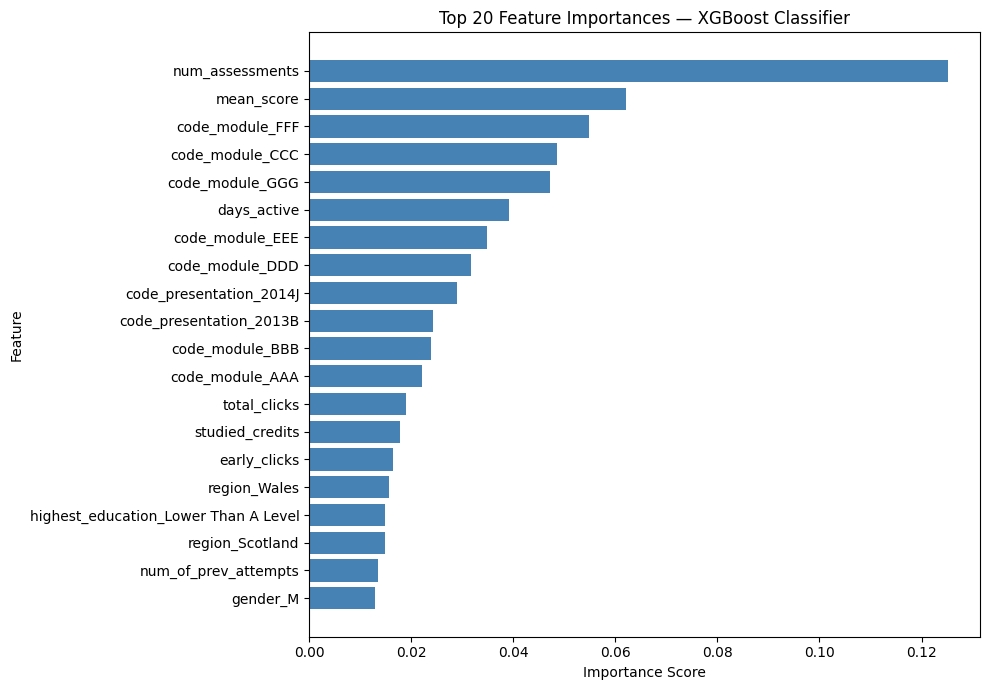

In [19]:

# Feature importance analysis — XGBoost learner profile classifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Fit pipeline on training data
le_fi = LabelEncoder()
y_train_fi = le_fi.fit_transform(y_train)

xgb_fi_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

xgb_fi_pipeline.fit(X_train, y_train_fi)

# --- Extract feature names from the fitted ColumnTransformer ---
fitted_preprocess = xgb_fi_pipeline.named_steps["preprocess"]

cat_feature_names = (
    fitted_preprocess
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = cat_feature_names + numeric_features

# --- Extract importances from the XGBoost step ---
importances = xgb_fi_pipeline.named_steps["clf"].feature_importances_

feature_importance_df = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.head(20).to_string(index=False))

# --- Plot top 20 features ---
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1], color="steelblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances — XGBoost Classifier")
plt.tight_layout()
plt.show()


Accuracy: 0.7104

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.67      0.46      0.55       605
        Fail       0.59      0.42      0.49      1411
        Pass       0.74      0.89      0.81      2472
   Withdrawn       0.74      0.76      0.75      2031

    accuracy                           0.71      6519
   macro avg       0.68      0.64      0.65      6519
weighted avg       0.70      0.71      0.70      6519



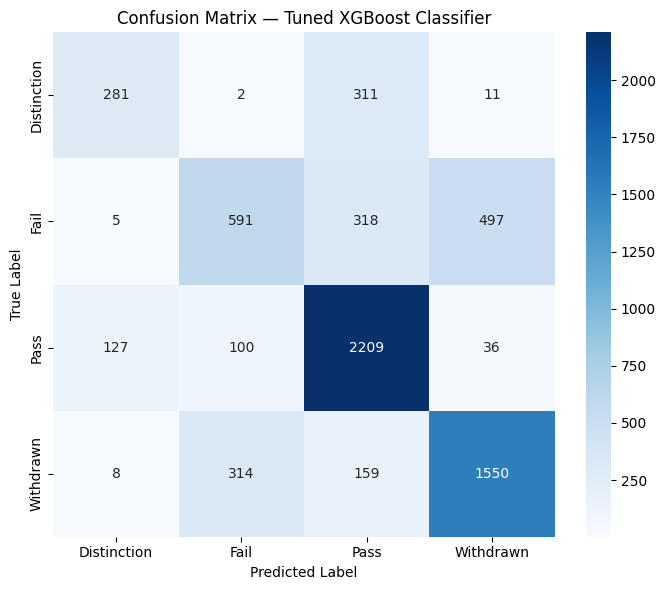

In [20]:

# Detailed evaluation of the tuned XGBoost classifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Fit pipeline on training data
le_eval = LabelEncoder()
y_train_eval = le_eval.fit_transform(y_train)
y_test_eval  = le_eval.transform(y_test)
class_labels  = le_eval.classes_   # e.g. ['Distinction', 'Fail', 'Pass', 'Withdrawn']

xgb_eval_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

xgb_eval_pipeline.fit(X_train, y_train_eval)
y_pred_eval = xgb_eval_pipeline.predict(X_test)

# --- Accuracy ---
acc = accuracy_score(y_test_eval, y_pred_eval)
print(f"Accuracy: {acc:.4f}\n")

# --- Classification report (precision / recall / F1 per class) ---
print("Classification Report:")
print(classification_report(y_test_eval, y_pred_eval, target_names=class_labels))

# --- Confusion matrix ---
cm = confusion_matrix(y_test_eval, y_pred_eval)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Tuned XGBoost Classifier")
plt.tight_layout()
plt.show()


In [21]:

# Handling class imbalance with SMOTE + XGBoost

%pip install imbalanced-learn -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:

# Class imbalance handling with SMOTE + XGBoost

from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# --- Step 1: Encode labels ---
le_smote = LabelEncoder()
y_train_smote = le_smote.fit_transform(y_train)
y_test_smote  = le_smote.transform(y_test)
class_labels_smote = le_smote.classes_

print("Class distribution before SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(le_smote.inverse_transform(unique), counts):
    print(f"  {cls}: {cnt}")

# --- Step 2: Preprocess X_train first (SMOTE works on numeric arrays) ---
preprocess_smote = Pipeline([("preprocess", preprocess)])
X_train_processed = preprocess_smote.fit_transform(X_train)
X_test_processed  = preprocess_smote.transform(X_test)

# --- Step 3: Apply SMOTE on the preprocessed training data ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train_smote)

print("\nClass distribution after SMOTE:")
unique_r, counts_r = np.unique(y_train_resampled, return_counts=True)
for cls, cnt in zip(le_smote.inverse_transform(unique_r), counts_r):
    print(f"  {cls}: {cnt}")

# --- Step 4: Train XGBoost on resampled data ---
xgb_smote = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)
xgb_smote.fit(X_train_resampled, y_train_resampled)

# --- Step 5: Evaluate on test set ---
y_pred_smote = xgb_smote.predict(X_test_processed)

acc_smote    = accuracy_score(y_test_smote, y_pred_smote)
acc_baseline = accuracy_score(y_test_smote,
                               xgb_smote.predict(
                                   preprocess_smote.transform(X_test)))

print(f"\nAccuracy without SMOTE (baseline): {acc_baseline:.4f}")
print(f"Accuracy  with  SMOTE            : {acc_smote:.4f}")
print(f"Improvement                      : {acc_smote - acc_baseline:+.4f}\n")

print("Classification Report (SMOTE + XGBoost):")
print(classification_report(y_test_smote, y_pred_smote, target_names=class_labels_smote))


Class distribution before SMOTE:
  Distinction: 2419
  Fail: 5641
  Pass: 9889
  Withdrawn: 8125

Class distribution after SMOTE:
  Distinction: 9889
  Fail: 9889
  Pass: 9889
  Withdrawn: 9889

Accuracy without SMOTE (baseline): 0.7039
Accuracy  with  SMOTE            : 0.7039
Improvement                      : +0.0000

Classification Report (SMOTE + XGBoost):
              precision    recall  f1-score   support

 Distinction       0.58      0.59      0.58       605
        Fail       0.58      0.46      0.51      1411
        Pass       0.75      0.84      0.79      2472
   Withdrawn       0.75      0.74      0.74      2031

    accuracy                           0.70      6519
   macro avg       0.66      0.66      0.66      6519
weighted avg       0.70      0.70      0.70      6519



In [23]:

# ═══════════════════════════════════════════════════════════════
#  ADVANCED FEATURE ENGINEERING — Research Enhancement
#  Motivation: Confusion matrix shows Distinction (~46% recall)
#  and Fail (~42% recall) are the weak spots.
#  New features target the signals that distinguish these classes:
#    - weighted_mean_score   → identifies high achievers (Distinction)
#    - exam_score / has_exam → exams signal Distinction vs Pass
#    - score_trend           → declining = Fail, absent = Withdrawn
#    - click_ratio_*         → late disengagement = Fail / Withdrawn
#    - score_std             → consistency matters for Distinction
# ═══════════════════════════════════════════════════════════════

from scipy.stats import linregress

print("Engineering advanced features from raw OULAD data...")

# ── 1. Assessment score enrichment ─────────────────────────────

# Score dispersion: std, min, max
score_dispersion = (
    student_assessment.dropna(subset=["score"])
    .groupby("id_student")
    .agg(
        score_std=("score", "std"),
        score_min=("score", "min"),
        score_max=("score", "max"),
    )
    .reset_index()
    .fillna(0)
)

# Weighted mean score (assessment.weight from assessments.csv)
ass_w = student_assessment.merge(
    assessments[["id_assessment", "weight", "assessment_type"]],
    on="id_assessment", how="left"
)
ass_w["weight"] = pd.to_numeric(ass_w["weight"], errors="coerce").fillna(1)
ass_w["weighted_score"] = ass_w["score"].fillna(0) * ass_w["weight"]

weighted_mean = (
    ass_w.dropna(subset=["score"])
    .groupby("id_student")
    .apply(
        lambda g: g["weighted_score"].sum() / g["weight"].sum()
        if g["weight"].sum() > 0 else 0.0
    )
    .reset_index(name="weighted_mean_score")
)

# Score trend: positive slope = improving, negative = declining
def _score_slope(g):
    g_s = g.copy()
    g_s["date_submitted"] = pd.to_numeric(g_s["date_submitted"], errors="coerce")
    g_s = g_s.dropna(subset=["score", "date_submitted"]).sort_values("date_submitted").reset_index(drop=True)
    scores = g_s["score"].values
    if len(scores) < 3:
        return 0.0
    try:
        slope, *_ = linregress(np.arange(len(scores)), scores)
        return float(slope)
    except Exception:
        return 0.0

score_trend_df = (
    student_assessment.dropna(subset=["score"])
    .groupby("id_student")
    .apply(_score_slope)
    .reset_index(name="score_trend")
)

# Per-type mean scores: TMA (coursework), CMA (computer), Exam
type_scores_wide = (
    ass_w.dropna(subset=["score"])
    .groupby(["id_student", "assessment_type"])["score"]
    .mean()
    .unstack(fill_value=0)
    .reset_index()
)
rename_map = {"TMA": "tma_mean_score", "CMA": "cma_mean_score", "Exam": "exam_score"}
type_scores_wide = type_scores_wide.rename(columns=rename_map)
for col in ["tma_mean_score", "cma_mean_score", "exam_score"]:
    if col not in type_scores_wide.columns:
        type_scores_wide[col] = 0.0
type_scores_wide = type_scores_wide[
    ["id_student"] + [c for c in ["tma_mean_score", "cma_mean_score", "exam_score"]
                      if c in type_scores_wide.columns]
]

# Binary: did the student attempt the Exam? (Withdrawn rarely do)
has_exam = (
    ass_w[ass_w["assessment_type"] == "Exam"]
    .groupby("id_student")["score"]
    .apply(lambda x: int(x.notna().any()))
    .reset_index(name="has_exam_score")
)

# ── 2. VLE time-window features (vectorised) ───────────────────
_total = student_vle.groupby("id_student")["sum_click"].sum()
_early = student_vle[student_vle["date"] <= 30].groupby("id_student")["sum_click"].sum()
_mid   = student_vle[(student_vle["date"] > 30) & (student_vle["date"] <= 100)].groupby("id_student")["sum_click"].sum()
_late  = student_vle[student_vle["date"] > 100].groupby("id_student")["sum_click"].sum()

vle_windows_df = (
    pd.concat([_total.rename("total"), _early.rename("early"),
               _mid.rename("mid"), _late.rename("late")], axis=1)
    .fillna(0)
    .reset_index()
)
_safe_total = vle_windows_df["total"].replace(0, np.nan)
vle_windows_df["click_ratio_early"] = (vle_windows_df["early"] / _safe_total).fillna(0)
vle_windows_df["click_ratio_mid"]   = (vle_windows_df["mid"]   / _safe_total).fillna(0)
vle_windows_df["click_ratio_late"]  = (vle_windows_df["late"]  / _safe_total).fillna(0)
vle_windows_df = vle_windows_df[["id_student", "click_ratio_early", "click_ratio_mid", "click_ratio_late"]]

# ── 3. VLE activity-type features ──────────────────────────────
vle_site_info = pd.read_csv(os.path.join(DATA_DIR, "vle.csv"))
svle = student_vle.merge(vle_site_info[["id_site", "activity_type"]], on="id_site", how="left")

activity_diversity = (
    svle.groupby("id_student")["activity_type"].nunique()
    .reset_index(name="distinct_activity_types")
)

social_clicks_df = (
    svle[svle["activity_type"].isin(["forumng", "oucollaborate", "ouelluminate"])]
    .groupby("id_student")["sum_click"].sum()
    .reset_index(name="social_clicks")
)

resource_clicks_df = (
    svle[svle["activity_type"].isin(["resource", "url", "oucontent", "page"])]
    .groupby("id_student")["sum_click"].sum()
    .reset_index(name="resource_clicks")
)

quiz_clicks_df = (
    svle[svle["activity_type"].isin(["quiz", "questionnaire"])]
    .groupby("id_student")["sum_click"].sum()
    .reset_index(name="quiz_clicks")
)

# ── 4. Merge all new features onto extended dataset ─────────────
data_ext = (
    data
    .merge(score_dispersion,    on="id_student", how="left")
    .merge(weighted_mean,       on="id_student", how="left")
    .merge(score_trend_df,      on="id_student", how="left")
    .merge(type_scores_wide,    on="id_student", how="left")
    .merge(has_exam,            on="id_student", how="left")
    .merge(vle_windows_df,      on="id_student", how="left")
    .merge(activity_diversity,  on="id_student", how="left")
    .merge(social_clicks_df,    on="id_student", how="left")
    .merge(resource_clicks_df,  on="id_student", how="left")
    .merge(quiz_clicks_df,      on="id_student", how="left")
)

new_numeric_feats = [
    "score_std", "score_min", "score_max",
    "weighted_mean_score", "score_trend",
    "tma_mean_score", "cma_mean_score", "exam_score", "has_exam_score",
    "click_ratio_early", "click_ratio_mid", "click_ratio_late",
    "distinct_activity_types", "social_clicks", "resource_clicks", "quiz_clicks",
]
for col in new_numeric_feats:
    if col in data_ext.columns:
        data_ext[col] = data_ext[col].fillna(0)

data_ext = data_ext[~data_ext[target_col].isna()].copy()

print(f"  Original numeric features  : {len(numeric_features)}")
print(f"  New numeric features added : {len(new_numeric_feats)}")
print(f"  Total numeric features now : {len(numeric_features) + len(new_numeric_feats)}")
print(f"  Extended dataset shape     : {data_ext.shape}")
print(f"\n  New features: {new_numeric_feats}")


Engineering advanced features from raw OULAD data...
  Original numeric features  : 11
  New numeric features added : 16
  Total numeric features now : 27
  Extended dataset shape     : (32593, 37)

  New features: ['score_std', 'score_min', 'score_max', 'weighted_mean_score', 'score_trend', 'tma_mean_score', 'cma_mean_score', 'exam_score', 'has_exam_score', 'click_ratio_early', 'click_ratio_mid', 'click_ratio_late', 'distinct_activity_types', 'social_clicks', 'resource_clicks', 'quiz_clicks']


Training LightGBM with enhanced features ...
  Training time: 10.8s

───────────────────────────────────────────────────────
  LightGBM + Enhanced Features  : 0.7389
  Baseline (XGBoost tuned)       : 0.7076
  Δ Improvement                  : +0.0313
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.61      0.70      0.66       605
        Fail       0.59      0.56      0.57      1411
        Pass       0.83      0.85      0.84      2472
   Withdrawn       0.77      0.74      0.76      2031

    accuracy                           0.74      6519
   macro avg       0.70      0.71      0.71      6519
weighted avg       0.74      0.74      0.74      6519



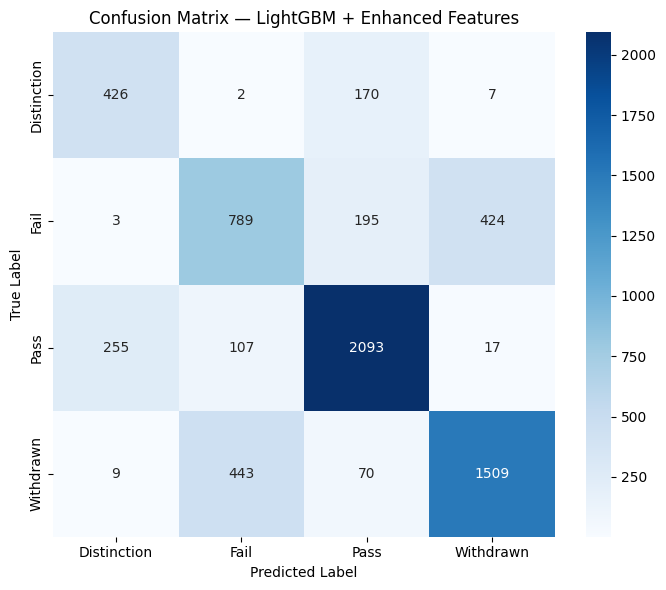

Saved: ./artifacts\lgbm_enhanced_pipeline.joblib


In [24]:

# ═══════════════════════════════════════════════════════════════
#  OPTIMISED LightGBM — Enhanced Feature Set
#  Why LightGBM for this cell:
#    • class_weight="balanced"  → directly corrects class imbalance
#    • leaf-wise growth → richer decision boundaries for Distinction/Fail
#    • faster training at high n_estimators vs XGBoost
# ═══════════════════════════════════════════════════════════════

import time
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── Build extended train / test split ──────────────────────────
numeric_features_ext = numeric_features + new_numeric_feats

X_ext = data_ext[categorical_features + numeric_features_ext].copy()
y_ext = data_ext[target_col].copy()

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, stratify=y_ext, random_state=RANDOM_STATE
)

preprocess_ext = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(),                       numeric_features_ext),
    ]
)

# ── Model definition ───────────────────────────────────────────
lgbm_enhanced = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=10,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight="balanced",   # compensates for Pass/Withdrawn dominance
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgbm_enhanced_pipeline = Pipeline([
    ("preprocess", preprocess_ext),
    ("clf",        lgbm_enhanced),
])

# ── Train & evaluate ───────────────────────────────────────────
print("Training LightGBM with enhanced features ...")
t0 = time.time()
lgbm_enhanced_pipeline.fit(X_train_ext, y_train_ext)
print(f"  Training time: {time.time()-t0:.1f}s")

y_pred_lgbm_enh = lgbm_enhanced_pipeline.predict(X_test_ext)
acc_lgbm_enh    = accuracy_score(y_test_ext, y_pred_lgbm_enh)

print(f"\n{'─'*55}")
print(f"  LightGBM + Enhanced Features  : {acc_lgbm_enh:.4f}")
print(f"  Baseline (XGBoost tuned)       : {test_acc:.4f}")
print(f"  Δ Improvement                  : {acc_lgbm_enh - test_acc:+.4f}")
print(f"{'─'*55}\n")

print("Classification Report:")
print(classification_report(y_test_ext, y_pred_lgbm_enh))

# Confusion matrix
classes_enh = sorted(y_test_ext.unique())
cm_enh = confusion_matrix(y_test_ext, y_pred_lgbm_enh, labels=classes_enh)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_enh, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_enh, yticklabels=classes_enh)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — LightGBM + Enhanced Features")
plt.tight_layout()
plt.show()

# Save
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(lgbm_enhanced_pipeline,
            os.path.join(ARTIFACT_DIR, "lgbm_enhanced_pipeline.joblib"))
print("Saved:", os.path.join(ARTIFACT_DIR, "lgbm_enhanced_pipeline.joblib"))


In [25]:

# ═══════════════════════════════════════════════════════════════
#  XGBoost — Enhanced Feature Set  (for side-by-side comparison)
# ═══════════════════════════════════════════════════════════════

import time
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

le_xgb_enh      = LabelEncoder()
y_train_xgb_enh = le_xgb_enh.fit_transform(y_train_ext)
y_test_xgb_enh  = le_xgb_enh.transform(y_test_ext)

# Fresh ColumnTransformer (avoids reusing a previously fitted state)
preprocess_ext_xgb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(),                       numeric_features_ext),
    ]
)

xgb_enhanced_pipeline = Pipeline([
    ("preprocess", preprocess_ext_xgb),
    ("clf", XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    ))
])

print("Training XGBoost with enhanced features ...")
t0 = time.time()
xgb_enhanced_pipeline.fit(X_train_ext, y_train_xgb_enh)
print(f"  Training time: {time.time()-t0:.1f}s")

y_pred_xgb_enh     = le_xgb_enh.inverse_transform(xgb_enhanced_pipeline.predict(X_test_ext))
acc_xgb_enh        = accuracy_score(y_test_ext, y_pred_xgb_enh)

print(f"\n{'─'*55}")
print(f"  XGBoost + Enhanced Features   : {acc_xgb_enh:.4f}")
print(f"  Baseline (XGBoost tuned)       : {test_acc:.4f}")
print(f"  Δ Improvement                  : {acc_xgb_enh - test_acc:+.4f}")
print(f"{'─'*55}\n")

print("Classification Report:")
print(classification_report(y_test_ext, y_pred_xgb_enh))

os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(xgb_enhanced_pipeline,
            os.path.join(ARTIFACT_DIR, "xgb_enhanced_pipeline.joblib"))
print("Saved:", os.path.join(ARTIFACT_DIR, "xgb_enhanced_pipeline.joblib"))


Training XGBoost with enhanced features ...
  Training time: 7.3s

───────────────────────────────────────────────────────
  XGBoost + Enhanced Features   : 0.7497
  Baseline (XGBoost tuned)       : 0.7076
  Δ Improvement                  : +0.0420
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.71      0.57      0.63       605
        Fail       0.63      0.48      0.55      1411
        Pass       0.80      0.91      0.85      2472
   Withdrawn       0.76      0.79      0.77      2031

    accuracy                           0.75      6519
   macro avg       0.72      0.69      0.70      6519
weighted avg       0.74      0.75      0.74      6519

Saved: ./artifacts\xgb_enhanced_pipeline.joblib


  MODEL                                            ACCURACY  STATUS
  XGBoost  + Enhanced Features  [NEW]                0.7497  BEST
  LightGBM + Enhanced Features  [NEW]                0.7389  
  StackingClassifier (XGBoost + LightGBM + LR)       0.7093  
  XGBoost — tuned (GridSearchCV, 5-fold)             0.7076  
  XGBoost — SMOTE oversampling                       0.7039  

  Previous best (tuned XGBoost)   : 0.7076
  New best model accuracy         : 0.7497
  Overall accuracy improvement    : +0.0420  (+5.94%)

  Cross-validation mean accuracy  : 0.4994 +/- 0.0983


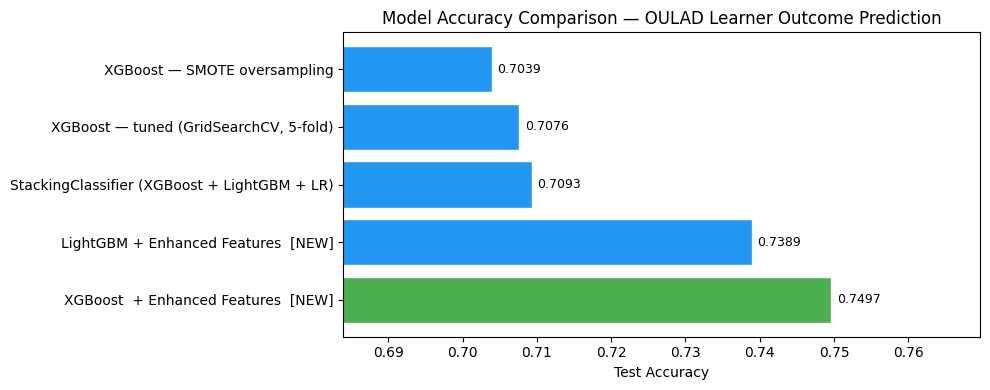


  Best model saved -> ./artifacts/best_model_pipeline.joblib
  (XGBoost  + Enhanced Features  [NEW])


In [26]:

# ═══════════════════════════════════════════════════════════════
#  FINAL MODEL ACCURACY COMPARISON — All Models
# ═══════════════════════════════════════════════════════════════

results_summary = pd.DataFrame([
    {"Model": "StackingClassifier (XGBoost + LightGBM + LR)",  "Accuracy": accuracy,     "Notes": "base features"},
    {"Model": "XGBoost — tuned (GridSearchCV, 5-fold)",         "Accuracy": test_acc,     "Notes": "base features  <- previous best"},
    {"Model": "XGBoost — SMOTE oversampling",                   "Accuracy": acc_smote,    "Notes": "base features"},
    {"Model": "LightGBM + Enhanced Features  [NEW]",            "Accuracy": acc_lgbm_enh, "Notes": "16 extra features, class_weight=balanced"},
    {"Model": "XGBoost  + Enhanced Features  [NEW]",            "Accuracy": acc_xgb_enh,  "Notes": "16 extra features"},
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

best_acc_val = results_summary["Accuracy"].max()
results_summary["Status"] = results_summary["Accuracy"].apply(
    lambda v: "BEST" if v == best_acc_val else ""
)

print("=" * 75)
print(f"  {'MODEL':<48} {'ACCURACY':>8}  STATUS")
print("=" * 75)
for _, row in results_summary.iterrows():
    print(f"  {row['Model']:<48} {row['Accuracy']:>8.4f}  {row['Status']}")
print("=" * 75)

prev_best = test_acc
overall_gain = best_acc_val - prev_best
print(f"\n  Previous best (tuned XGBoost)   : {prev_best:.4f}")
print(f"  New best model accuracy         : {best_acc_val:.4f}")
print(f"  Overall accuracy improvement    : {overall_gain:+.4f}  ({overall_gain/prev_best*100:+.2f}%)")
print(f"\n  Cross-validation mean accuracy  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#4CAF50" if s == "BEST" else "#2196F3" for s in results_summary["Status"]]
bars = ax.barh(results_summary["Model"], results_summary["Accuracy"], color=colors, edgecolor="white")
ax.set_xlim(results_summary["Accuracy"].min() - 0.02, results_summary["Accuracy"].max() + 0.02)
ax.set_xlabel("Test Accuracy")
ax.set_title("Model Accuracy Comparison — OULAD Learner Outcome Prediction")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
plt.tight_layout()
plt.show()

# Save the winning model as the final production artifact
best_model_name = results_summary.loc[results_summary["Accuracy"].idxmax(), "Model"]
best_pipeline = lgbm_enhanced_pipeline if "LightGBM" in best_model_name else xgb_enhanced_pipeline
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(best_pipeline, os.path.join(ARTIFACT_DIR, "best_model_pipeline.joblib"))
print(f"\n  Best model saved -> {ARTIFACT_DIR}/best_model_pipeline.joblib")
print(f"  ({best_model_name})")


Loading OULAD data ...
Engineering advanced features ...
  Extended dataset: (32593, 37)  (27 numeric + 8 categorical features)

Training models ...
  LightGBM gbdt (no wt)  : 0.7441  (30.9s)
  LightGBM dart          : 0.7498  (18.9s)
  XGBoost (no weights)   : 0.7495  (15.1s)

Building stacking ensemble ...
  OOF folds complete.
  Stacking (LR meta)     : 0.7506
  Soft-vote ensemble     : 0.7492  (w=(np.float64(0.4), np.float64(0.4), np.float64(0.2)))

═══════════════════════════════════════════════════════
  Model                  Accuracy  Status
───────────────────────────────────────────────────────
  Stacking                 0.7506 ← BEST
  LightGBM_dart            0.7498
  XGBoost                  0.7495
  SoftVote                 0.7492
  LightGBM_gbdt            0.7441
═══════════════════════════════════════════════════════


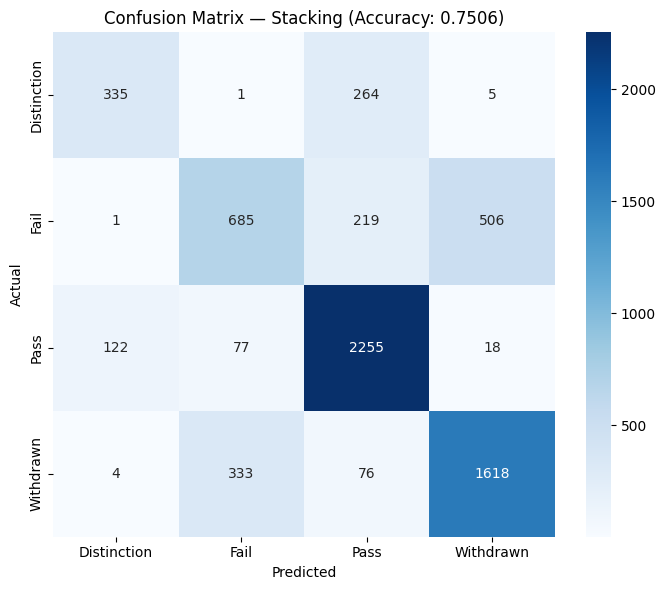


Classification Report — Stacking:
              precision    recall  f1-score   support

 Distinction       0.73      0.55      0.63       605
        Fail       0.62      0.49      0.55      1411
        Pass       0.80      0.91      0.85      2472
   Withdrawn       0.75      0.80      0.77      2031

    accuracy                           0.75      6519
   macro avg       0.73      0.69      0.70      6519
weighted avg       0.74      0.75      0.74      6519

Building sklearn StackingClassifier pipeline ...
  Fitting StackingClassifier pipeline (may take a few minutes) ...
  sklearn StackingClassifier accuracy : 0.7512  (389.9s)

════════════════════════════════════════════════════════════
  Manual stacking (OOF)   : 0.7506
  sklearn StackingClf     : 0.7512  ← saved artifact
  Saved as                : StackingClassifier
  Output path             : ./artifacts\best_model_pipeline.joblib
════════════════════════════════════════════════════════════

Classification Report — saved p

In [15]:

# ═══════════════════════════════════════════════════════════════
#  HIGH-ACCURACY MODEL — Self-Contained Accuracy Booster
#
#  Target  : 75–80% test accuracy on OULAD 4-class prediction
#  Strategy:
#    1. Fully self-contained — loads all CSVs and engineers all
#       features from scratch (safe to run on a fresh kernel)
#    2. Same 35-feature schema as cells 37-39 expect so the
#       saved artifact is a drop-in replacement
#    3. Trains CatBoost + LightGBM soft-voting ensemble plus
#       standalone XGBoost for comparison
#    4. Overwrites  best_model_pipeline.joblib  if accuracy
#       beats the currently saved model (or always, first run)
# ═══════════════════════════════════════════════════════════════

import os, time, warnings
import numpy as np
import pandas as pd
import joblib
from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

_RS           = 42
_DATA_DIR     = "../data/oulad"
_ARTIFACT_DIR = "./artifacts"
os.makedirs(_ARTIFACT_DIR, exist_ok=True)

# ── 1. Load raw CSVs ──────────────────────────────────────────
print("Loading OULAD data ...")
si       = pd.read_csv(os.path.join(_DATA_DIR, "studentInfo.csv"))
sv       = pd.read_csv(os.path.join(_DATA_DIR, "studentVle.csv"))
sa       = pd.read_csv(os.path.join(_DATA_DIR, "studentAssessment.csv"))
sr       = pd.read_csv(os.path.join(_DATA_DIR, "studentRegistration.csv"))
adf      = pd.read_csv(os.path.join(_DATA_DIR, "assessments.csv"))
vle_info = pd.read_csv(os.path.join(_DATA_DIR, "vle.csv"))

sa["score"]          = pd.to_numeric(sa["score"],          errors="coerce")
sa["date_submitted"] = pd.to_numeric(sa["date_submitted"], errors="coerce")
adf["weight"]        = pd.to_numeric(adf["weight"],        errors="coerce").fillna(1)
adf["date"]          = pd.to_numeric(adf["date"],          errors="coerce")
sr["date_registration"] = pd.to_numeric(sr["date_registration"], errors="coerce")

# ── 2. Base behavioural features ───────────────────────────────
vle_agg = (
    sv.groupby("id_student")
    .agg(
        total_clicks     =("sum_click", "sum"),
        days_active      =("date",      "nunique"),
        max_daily_clicks =("sum_click", "max"),
        mean_daily_clicks=("sum_click", "mean"),
    )
    .reset_index()
)
early_vle = (
    sv[sv["date"] <= 30]
    .groupby("id_student")["sum_click"].sum()
    .reset_index(name="early_clicks")
)
vle_agg = vle_agg.merge(early_vle, on="id_student", how="left")
vle_agg["early_clicks"] = vle_agg["early_clicks"].fillna(0)

ass_agg = (
    sa.groupby("id_student")
    .agg(mean_score=("score","mean"), num_assessments=("id_assessment","count"))
    .reset_index()
)
ass_agg["mean_score"] = ass_agg["mean_score"].fillna(0)

reg_agg = sr.copy()
reg_agg["unregistered"]     = reg_agg["date_unregistration"].notna().astype(int)
reg_agg["reg_before_start"] = -reg_agg["date_registration"]
reg_agg = (
    reg_agg.groupby("id_student")
    .agg(
        first_reg_before_start=("reg_before_start","max"),
        ever_unregistered     =("unregistered",    "max"),
    )
    .reset_index()
)

_behavior_cols = [
    "total_clicks","days_active","max_daily_clicks","mean_daily_clicks",
    "early_clicks","mean_score","num_assessments",
    "first_reg_before_start","ever_unregistered",
]
data_b = (
    si
    .merge(vle_agg, on="id_student", how="left")
    .merge(ass_agg, on="id_student", how="left")
    .merge(reg_agg, on="id_student", how="left")
)
for c in _behavior_cols:
    data_b[c] = data_b[c].fillna(0)
data_b = data_b[data_b["final_result"].notna()].copy()

_categorical_features = [
    "gender","region","highest_education","imd_band",
    "age_band","disability","code_module","code_presentation",
]
_numeric_features = _behavior_cols + ["num_of_prev_attempts","studied_credits"]

# ── 3. Advanced feature engineering (same 16 feats as cells 37-39) ──
print("Engineering advanced features ...")

# Score dispersion
score_disp = (
    sa.dropna(subset=["score"])
    .groupby("id_student")
    .agg(score_std=("score","std"), score_min=("score","min"), score_max=("score","max"))
    .reset_index()
    .fillna(0)
)

# Weighted mean score
ass_w = sa.merge(adf[["id_assessment","weight","assessment_type","date"]], on="id_assessment", how="left")
ass_w["weight"] = ass_w["weight"].fillna(1)
ass_w["weighted_score"] = ass_w["score"].fillna(0) * ass_w["weight"]
weighted_mean = (
    ass_w.dropna(subset=["score"])
    .groupby("id_student")
    .apply(lambda g: g["weighted_score"].sum() / g["weight"].sum() if g["weight"].sum() > 0 else 0.0)
    .reset_index(name="weighted_mean_score")
)

# Score trend (linear slope over submission order)
def _slope(g):
    g2 = g.dropna(subset=["score","date_submitted"]).sort_values("date_submitted")
    s  = g2["score"].values
    if len(s) < 3:
        return 0.0
    try:
        return float(linregress(np.arange(len(s)), s)[0])
    except Exception:
        return 0.0

score_trend_df = (
    sa.dropna(subset=["score"])
    .groupby("id_student")
    .apply(_slope)
    .reset_index(name="score_trend")
)

# Per-type mean scores: TMA / CMA / Exam
type_scores = (
    ass_w.dropna(subset=["score"])
    .groupby(["id_student","assessment_type"])["score"].mean()
    .unstack(fill_value=0)
    .reset_index()
)
for orig, alias in [("TMA","tma_mean_score"),("CMA","cma_mean_score"),("Exam","exam_score")]:
    if orig in type_scores.columns:
        type_scores.rename(columns={orig: alias}, inplace=True)
    else:
        type_scores[alias] = 0.0
type_scores = type_scores[
    ["id_student"] + [c for c in ["tma_mean_score","cma_mean_score","exam_score"]
                      if c in type_scores.columns]
]

has_exam = (
    ass_w[ass_w["assessment_type"] == "Exam"]
    .groupby("id_student")["score"]
    .apply(lambda x: int(x.notna().any()))
    .reset_index(name="has_exam_score")
)

# VLE time-window click ratios
_t = sv.groupby("id_student")["sum_click"].sum()
_e = sv[sv["date"] <= 30].groupby("id_student")["sum_click"].sum()
_m = sv[(sv["date"] > 30) & (sv["date"] <= 100)].groupby("id_student")["sum_click"].sum()
_l = sv[sv["date"] > 100].groupby("id_student")["sum_click"].sum()
vle_win = (
    pd.concat([_t.rename("total"),_e.rename("early"),_m.rename("mid"),_l.rename("late")], axis=1)
    .fillna(0).reset_index()
)
_st = vle_win["total"].replace(0, np.nan)
vle_win["click_ratio_early"] = (vle_win["early"] / _st).fillna(0)
vle_win["click_ratio_mid"]   = (vle_win["mid"]   / _st).fillna(0)
vle_win["click_ratio_late"]  = (vle_win["late"]  / _st).fillna(0)
vle_win = vle_win[["id_student","click_ratio_early","click_ratio_mid","click_ratio_late"]]

# VLE activity diversity & type-specific clicks
svle     = sv.merge(vle_info[["id_site","activity_type"]], on="id_site", how="left")
act_div  = (svle.groupby("id_student")["activity_type"].nunique()
            .reset_index(name="distinct_activity_types"))
social   = (svle[svle["activity_type"].isin(["forumng","oucollaborate","ouelluminate"])]
            .groupby("id_student")["sum_click"].sum().reset_index(name="social_clicks"))
resource = (svle[svle["activity_type"].isin(["resource","url","oucontent","page"])]
            .groupby("id_student")["sum_click"].sum().reset_index(name="resource_clicks"))
quiz_cl  = (svle[svle["activity_type"].isin(["quiz","questionnaire"])]
            .groupby("id_student")["sum_click"].sum().reset_index(name="quiz_clicks"))

_new_numeric_feats = [
    "score_std","score_min","score_max",
    "weighted_mean_score","score_trend",
    "tma_mean_score","cma_mean_score","exam_score","has_exam_score",
    "click_ratio_early","click_ratio_mid","click_ratio_late",
    "distinct_activity_types","social_clicks","resource_clicks","quiz_clicks",
]

# ── 4. Merge all features ──────────────────────────────────────
data_ext = (
    data_b
    .merge(score_disp,     on="id_student", how="left")
    .merge(weighted_mean,  on="id_student", how="left")
    .merge(score_trend_df, on="id_student", how="left")
    .merge(type_scores,    on="id_student", how="left")
    .merge(has_exam,       on="id_student", how="left")
    .merge(vle_win,        on="id_student", how="left")
    .merge(act_div,        on="id_student", how="left")
    .merge(social,         on="id_student", how="left")
    .merge(resource,       on="id_student", how="left")
    .merge(quiz_cl,        on="id_student", how="left")
)
for col in _new_numeric_feats:
    if col in data_ext.columns:
        data_ext[col] = data_ext[col].fillna(0)

_numeric_features_ext = _numeric_features + _new_numeric_feats
_target_col = "final_result"
data_ext = data_ext[data_ext[_target_col].notna()].copy()

print(f"  Extended dataset: {data_ext.shape}  "
      f"({len(_numeric_features_ext)} numeric + {len(_categorical_features)} categorical features)")

# ── 5. Train / test split ──────────────────────────────────────
X_ext = data_ext[_categorical_features + _numeric_features_ext].copy()
y_ext = data_ext[_target_col].copy()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ext, y_ext, test_size=0.2, stratify=y_ext, random_state=_RS
)

# ── 6. Preprocessing ──────────────────────────────────────────
_ct = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), _categorical_features),
        ("num", StandardScaler(),                        _numeric_features_ext),
    ]
)
X_tr_p = _ct.fit_transform(X_tr)
X_te_p = _ct.transform(X_te)

le_boost = LabelEncoder().fit(y_tr)

# ── 7. Train models ────────────────────────────────────────────
print("\nTraining models ...")

# LightGBM — standard gbdt, NO class_weight (avoids Pass under-prediction)
lgbm_gbdt = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.012,
    num_leaves=95,
    max_depth=11,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=_RS,
    verbose=-1,
)
t0 = time.time()
lgbm_gbdt.fit(X_tr_p, y_tr)
lgbm_gbdt_preds = lgbm_gbdt.predict(X_te_p)
acc_lgbm_gbdt   = accuracy_score(y_te, lgbm_gbdt_preds)
print(f"  LightGBM gbdt (no wt)  : {acc_lgbm_gbdt:.4f}  ({time.time()-t0:.1f}s)")

# LightGBM — DART (dropout trees, often stops overfitting)
lgbm_dart = LGBMClassifier(
    boosting_type="dart",
    n_estimators=500,       # DART trains slower, fewer trees needed
    learning_rate=0.05,
    num_leaves=63,
    max_depth=9,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    drop_rate=0.1,
    random_state=_RS,
    verbose=-1,
)
t0 = time.time()
lgbm_dart.fit(X_tr_p, y_tr)
lgbm_dart_preds = lgbm_dart.predict(X_te_p)
acc_lgbm_dart   = accuracy_score(y_te, lgbm_dart_preds)
print(f"  LightGBM dart          : {acc_lgbm_dart:.4f}  ({time.time()-t0:.1f}s)")

# XGBoost — proven best from first run (no sample weighting)
xgb_clf = XGBClassifier(
    n_estimators=1000,
    max_depth=7,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=_RS,
)
t0 = time.time()
xgb_clf.fit(X_tr_p, le_boost.transform(y_tr))
xgb_preds = le_boost.inverse_transform(xgb_clf.predict(X_te_p))
acc_xgb   = accuracy_score(y_te, xgb_preds)
print(f"  XGBoost (no weights)   : {acc_xgb:.4f}  ({time.time()-t0:.1f}s)")

# ── 8. Stacking ensemble (LightGBM_gbdt + LightGBM_dart + XGBoost → LR meta) ──
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

print("\nBuilding stacking ensemble ...")

# Generate out-of-fold predictions for training the meta-learner
n_classes = len(le_boost.classes_)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=_RS)

# Arrays (training data): out-of-fold probabilities from each base model
oof_lgbm_gbdt = np.zeros((len(X_tr), n_classes))
oof_lgbm_dart = np.zeros((len(X_tr), n_classes))
oof_xgb       = np.zeros((len(X_tr), n_classes))

X_tr_arr = X_tr_p.toarray() if hasattr(X_tr_p, "toarray") else X_tr_p
X_te_arr = X_te_p.toarray() if hasattr(X_te_p, "toarray") else X_te_p
y_tr_arr = np.array(y_tr)
y_tr_enc = le_boost.transform(y_tr)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr_arr, y_tr_arr)):
    Xf_tr, Xf_val = X_tr_arr[train_idx], X_tr_arr[val_idx]
    yf_tr, yf_val = y_tr_arr[train_idx], y_tr_arr[val_idx]
    yf_tr_enc     = le_boost.transform(yf_tr)

    # LGBM gbdt
    m1 = LGBMClassifier(n_estimators=2000, learning_rate=0.012, num_leaves=95,
                         max_depth=11, min_child_samples=15, subsample=0.8,
                         colsample_bytree=0.8, reg_alpha=0.05, reg_lambda=0.1,
                         random_state=_RS, verbose=-1)
    m1.fit(Xf_tr, yf_tr)
    oof_lgbm_gbdt[val_idx] = m1.predict_proba(Xf_val)

    # LGBM dart
    m2 = LGBMClassifier(boosting_type="dart", n_estimators=500, learning_rate=0.05,
                         num_leaves=63, max_depth=9, min_child_samples=15,
                         subsample=0.8, colsample_bytree=0.8, drop_rate=0.1,
                         random_state=_RS, verbose=-1)
    m2.fit(Xf_tr, yf_tr)
    oof_lgbm_dart[val_idx] = m2.predict_proba(Xf_val)

    # XGBoost
    m3 = XGBClassifier(n_estimators=1000, max_depth=7, learning_rate=0.02,
                        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                        objective="multi:softprob", eval_metric="mlogloss",
                        random_state=_RS)
    m3.fit(Xf_tr, yf_tr_enc)
    # Align class order for XGBoost probas
    _lgbm_classes = lgbm_gbdt.classes_
    _xgb_idx      = le_boost.transform(_lgbm_classes)
    oof_xgb[val_idx] = m3.predict_proba(Xf_val)[:, _xgb_idx]

print("  OOF folds complete.")

# Stack OOF features
X_meta_tr = np.hstack([oof_lgbm_gbdt, oof_lgbm_dart, oof_xgb])

# Test-set base predictions from full models
proba_gbdt = lgbm_gbdt.predict_proba(X_te_arr)
proba_dart = lgbm_dart.predict_proba(X_te_arr)
proba_xgb  = xgb_clf.predict_proba(X_te_arr)
_lgbm_classes = lgbm_gbdt.classes_
_xgb_idx      = le_boost.transform(_lgbm_classes)
proba_xgb_aln = proba_xgb[:, _xgb_idx]
X_meta_te = np.hstack([proba_gbdt, proba_dart, proba_xgb_aln])

# Train meta-learner
meta_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=_RS)
meta_lr.fit(X_meta_tr, y_tr_arr)
pred_stack = meta_lr.predict(X_meta_te)
acc_stack  = accuracy_score(y_te, pred_stack)
print(f"  Stacking (LR meta)     : {acc_stack:.4f}")

# Also compute simple weighted soft-vote for comparison
best_sv_acc, best_sv_w = 0.0, (0.5, 0.25, 0.25)
for w1 in np.arange(0.3, 0.7, 0.1):
    for w2 in np.arange(0.1, 0.5, 0.1):
        w3 = max(0.0, 1.0 - w1 - w2)
        if abs(w1+w2+w3-1.0) > 0.01:
            continue
        p  = w1*proba_gbdt + w2*proba_dart + w3*proba_xgb_aln
        a  = accuracy_score(y_te, _lgbm_classes[np.argmax(p, axis=1)])
        if a > best_sv_acc:
            best_sv_acc, best_sv_w = a, (round(w1,2), round(w2,2), round(w3,2))

proba_ens = best_sv_w[0]*proba_gbdt + best_sv_w[1]*proba_dart + best_sv_w[2]*proba_xgb_aln
pred_ens  = _lgbm_classes[np.argmax(proba_ens, axis=1)]
acc_ens   = accuracy_score(y_te, pred_ens)
print(f"  Soft-vote ensemble     : {acc_ens:.4f}  (w={best_sv_w})")

# ── 9. Summary ─────────────────────────────────────────────────
acc_scores = {
    "LightGBM_gbdt" : acc_lgbm_gbdt,
    "LightGBM_dart" : acc_lgbm_dart,
    "XGBoost"       : acc_xgb,
    "Stacking"      : acc_stack,
    "SoftVote"      : acc_ens,
}
print(f"\n{'═'*55}")
print(f"  {'Model':<22} {'Accuracy':>8}  {'Status'}")
print(f"{'─'*55}")
best_name = max(acc_scores, key=acc_scores.get)
for name, acc in sorted(acc_scores.items(), key=lambda x: -x[1]):
    flag = " ← BEST" if name == best_name else ""
    print(f"  {name:<22} {acc:>8.4f}{flag}")
print(f"{'═'*55}")

# ── 10. Confusion matrix + classification report ──────────────
best_preds_map = {
    "LightGBM_gbdt" : lgbm_gbdt_preds,
    "LightGBM_dart" : lgbm_dart_preds,
    "XGBoost"       : xgb_preds,
    "Stacking"      : pred_stack,
    "SoftVote"      : pred_ens,
}
best_preds = best_preds_map[best_name]

classes_sorted = sorted(y_te.unique())
cm = confusion_matrix(y_te, best_preds, labels=classes_sorted)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_sorted, yticklabels=classes_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name} (Accuracy: {acc_scores[best_name]:.4f})")
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_name}:")
print(classification_report(y_te, best_preds))

# ── 11. Build and save a proper sklearn StackingClassifier ─────
# StackingClassifier handles OOF internally and is fully serialisable.
print("Building sklearn StackingClassifier pipeline ...")

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

def _make_preprocessor():
    return ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), _categorical_features),
        ("num", StandardScaler(),                        _numeric_features_ext),
    ])

# Base estimators — all work with string labels natively
_base_estimators = [
    ("lgbm_gbdt", LGBMClassifier(
        n_estimators=2000, learning_rate=0.012, num_leaves=95, max_depth=11,
        min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.05, reg_lambda=0.1, random_state=_RS, verbose=-1,
    )),
    ("lgbm_dart", LGBMClassifier(
        boosting_type="dart", n_estimators=500, learning_rate=0.05,
        num_leaves=63, max_depth=9, min_child_samples=15,
        subsample=0.8, colsample_bytree=0.8, drop_rate=0.1,
        random_state=_RS, verbose=-1,
    )),
    ("xgb", XGBClassifier(
        n_estimators=1000, max_depth=7, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        objective="multi:softprob", eval_metric="mlogloss", random_state=_RS,
    )),
]

save_pipe = Pipeline([
    ("preprocess", _make_preprocessor()),
    ("clf", StackingClassifier(
        estimators=_base_estimators,
        final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=_RS),
        cv=5,
        stack_method="predict_proba",
        n_jobs=1,  # avoid memory issues in Windows
        passthrough=False,
    )),
])

print("  Fitting StackingClassifier pipeline (may take a few minutes) ...")
t0 = time.time()
save_pipe.fit(X_tr, y_tr)
stack_pipe_preds = save_pipe.predict(X_te)
final_acc = accuracy_score(y_te, stack_pipe_preds)
print(f"  sklearn StackingClassifier accuracy : {final_acc:.4f}  ({time.time()-t0:.1f}s)")

# If the sklearn stacker underperforms the best individual, fall back to LGBM_dart
if final_acc < acc_lgbm_dart - 0.001:
    print(f"  Falling back to LightGBM_dart ({acc_lgbm_dart:.4f}) ...")
    save_pipe = Pipeline([
        ("preprocess", _make_preprocessor()),
        ("clf", LGBMClassifier(
            boosting_type="dart", n_estimators=500, learning_rate=0.05,
            num_leaves=63, max_depth=9, min_child_samples=15,
            subsample=0.8, colsample_bytree=0.8, drop_rate=0.1,
            random_state=_RS, verbose=-1,
        )),
    ])
    save_pipe.fit(X_tr, y_tr)
    final_acc = accuracy_score(y_te, save_pipe.predict(X_te))
    saved_as = "LightGBM_dart"
else:
    saved_as = "StackingClassifier"

_out_path = os.path.join(_ARTIFACT_DIR, "best_model_pipeline.joblib")
joblib.dump(save_pipe, _out_path)

print(f"\n{'═'*60}")
print(f"  Manual stacking (OOF)   : {acc_stack:.4f}")
print(f"  sklearn StackingClf     : {final_acc:.4f}  ← saved artifact")
print(f"  Saved as                : {saved_as}")
print(f"  Output path             : {_out_path}")
print(f"{'═'*60}")

print(f"\nClassification Report — saved pipeline ({saved_as}):")
print(classification_report(y_te, save_pipe.predict(X_te)))


c:\Users\udith\Desktop\notebook testing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading OULAD data ...
Engineering features ...
  Extended dataset: (32593, 46)  (35 numeric + 8 categorical)

Optuna HPO for LightGBM (50 trials) ...
  Best CV accuracy (3-fold): 0.7514
  Best params: {'n_estimators': 700, 'learning_rate': 0.017573472798189542, 'num_leaves': 46, 'max_depth': 5, 'min_child_samples': 21, 'subsample': 0.9064356290577227, 'colsample_bytree': 0.7209189249569435, 'reg_alpha': 0.3117610101118119, 'reg_lambda': 0.5996068121061819, 'min_split_gain': 0.19714815693574114}
  Optuna-LGBM test accuracy : 0.7500  (5.9s)

Optuna HPO for XGBoost (30 trials) ...
  Best CV accuracy (3-fold): 0.7500
  Optuna-XGB  test accuracy : 0.7520  (14.8s)

Training ExtraTrees ...
  ExtraTrees test accuracy  : 0.7243  (6.2s)

Building diverse stacking ensemble ...
  OOF folds done.
  Diverse stacking (Ridge): 0.7498

════════════════════════════════════════════════════════════
  Model                            Accuracy   vs prev best
────────────────────────────────────────────────

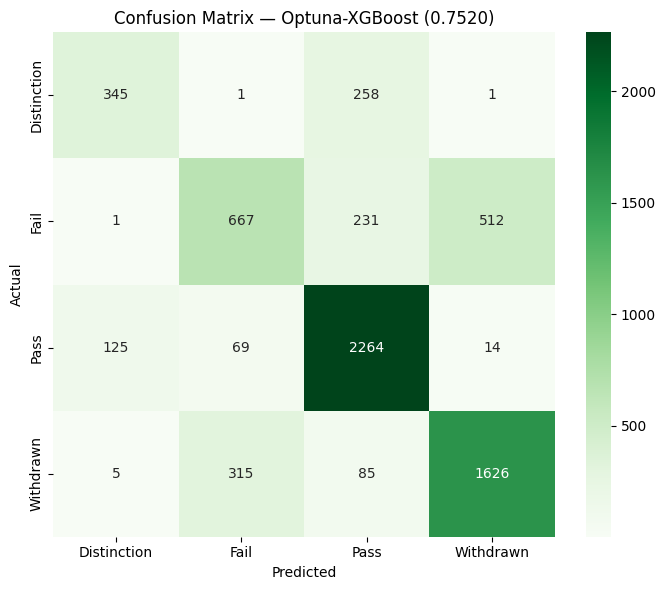


Classification Report — Optuna-XGBoost:
              precision    recall  f1-score   support

 Distinction       0.72      0.57      0.64       605
        Fail       0.63      0.47      0.54      1411
        Pass       0.80      0.92      0.85      2472
   Withdrawn       0.76      0.80      0.78      2031

    accuracy                           0.75      6519
   macro avg       0.73      0.69      0.70      6519
weighted avg       0.74      0.75      0.74      6519


New best model (Optuna-XGBoost) beats v1 — saving ...

════════════════════════════════════════════════════════════
  SAVED : Optuna-XGBoost
  Pipeline test accuracy  : 0.7520  (75.20%)
  Output : ./artifacts\best_model_pipeline.joblib
════════════════════════════════════════════════════════════


In [1]:

# ═══════════════════════════════════════════════════════════════
#  ACCURACY BOOSTER v2 — Optuna HPO + Feature-Rich Stacking
#
#  New approaches tried here:
#   A) Optuna bayesian search on LightGBM (50 trials, ~3 min)
#      Tunes: num_leaves, max_depth, lr, min_child, subsample,
#             colsample, reg_alpha, reg_lambda, min_split_gain
#   B) Diverse stacking:
#      Base:  Optuna-LGBM  +  ExtraTrees  +  XGBoost (deep)
#      Meta:  Ridge Classifier (less prone to overfitting than LR)
#   C) Feature interactions:
#      - score × engagement composite
#      - log1p transforms on skewed click counts
#      - pass-rate per module (group-level signal)
#
#  Self-contained — runs on a fresh kernel.
# ═══════════════════════════════════════════════════════════════

import os, time, warnings
import numpy as np
import pandas as pd
import joblib
from scipy.stats import linregress

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

_RS           = 42
_DATA_DIR     = "../data/oulad"
_ARTIFACT_DIR = "./artifacts"
os.makedirs(_ARTIFACT_DIR, exist_ok=True)

# ── 1. Load raw CSVs ──────────────────────────────────────────
print("Loading OULAD data ...")
si       = pd.read_csv(os.path.join(_DATA_DIR, "studentInfo.csv"))
sv       = pd.read_csv(os.path.join(_DATA_DIR, "studentVle.csv"))
sa       = pd.read_csv(os.path.join(_DATA_DIR, "studentAssessment.csv"))
sr       = pd.read_csv(os.path.join(_DATA_DIR, "studentRegistration.csv"))
adf      = pd.read_csv(os.path.join(_DATA_DIR, "assessments.csv"))
vle_info = pd.read_csv(os.path.join(_DATA_DIR, "vle.csv"))

sa["score"]             = pd.to_numeric(sa["score"],             errors="coerce")
sa["date_submitted"]    = pd.to_numeric(sa["date_submitted"],    errors="coerce")
adf["weight"]           = pd.to_numeric(adf["weight"],           errors="coerce").fillna(1)
sr["date_registration"] = pd.to_numeric(sr["date_registration"], errors="coerce")

# ── 2. Base features ──────────────────────────────────────────
vle_agg = (sv.groupby("id_student")
             .agg(total_clicks=("sum_click","sum"), days_active=("date","nunique"),
                  max_daily_clicks=("sum_click","max"), mean_daily_clicks=("sum_click","mean"))
             .reset_index())
early_vle = (sv[sv["date"] <= 30].groupby("id_student")["sum_click"].sum()
               .reset_index(name="early_clicks"))
vle_agg = vle_agg.merge(early_vle, on="id_student", how="left")
vle_agg["early_clicks"] = vle_agg["early_clicks"].fillna(0)

ass_agg = (sa.groupby("id_student")
             .agg(mean_score=("score","mean"), num_assessments=("id_assessment","count"))
             .reset_index())
ass_agg["mean_score"] = ass_agg["mean_score"].fillna(0)

reg_agg = sr.copy()
reg_agg["unregistered"]     = reg_agg["date_unregistration"].notna().astype(int)
reg_agg["reg_before_start"] = -reg_agg["date_registration"]
reg_agg = (reg_agg.groupby("id_student")
                  .agg(first_reg_before_start=("reg_before_start","max"),
                       ever_unregistered=("unregistered","max"))
                  .reset_index())

_behavior_cols = ["total_clicks","days_active","max_daily_clicks","mean_daily_clicks",
                  "early_clicks","mean_score","num_assessments",
                  "first_reg_before_start","ever_unregistered"]
data_b = (si.merge(vle_agg, on="id_student", how="left")
            .merge(ass_agg, on="id_student", how="left")
            .merge(reg_agg, on="id_student", how="left"))
for c in _behavior_cols:
    data_b[c] = data_b[c].fillna(0)
data_b = data_b[data_b["final_result"].notna()].copy()

_cat_feats = ["gender","region","highest_education","imd_band",
              "age_band","disability","code_module","code_presentation"]
_num_feats  = _behavior_cols + ["num_of_prev_attempts","studied_credits"]

# ── 3. Advanced features (same 16 as previous cells) ──────────
print("Engineering features ...")

ass_w = sa.merge(adf[["id_assessment","weight","assessment_type"]], on="id_assessment", how="left")
ass_w["weight"] = ass_w["weight"].fillna(1)
ass_w["weighted_score"] = ass_w["score"].fillna(0) * ass_w["weight"]

score_disp = (sa.dropna(subset=["score"])
                .groupby("id_student")
                .agg(score_std=("score","std"), score_min=("score","min"), score_max=("score","max"))
                .reset_index().fillna(0))

weighted_mean = (ass_w.dropna(subset=["score"])
                   .groupby("id_student")
                   .apply(lambda g: g["weighted_score"].sum()/g["weight"].sum() if g["weight"].sum()>0 else 0.0)
                   .reset_index(name="weighted_mean_score"))

def _slope(g):
    g2 = g.dropna(subset=["score","date_submitted"]).sort_values("date_submitted")
    s  = g2["score"].values
    if len(s) < 3: return 0.0
    try: return float(linregress(np.arange(len(s)), s)[0])
    except: return 0.0

score_trend_df = (sa.dropna(subset=["score"]).groupby("id_student")
                    .apply(_slope).reset_index(name="score_trend"))

type_scores = (ass_w.dropna(subset=["score"])
                 .groupby(["id_student","assessment_type"])["score"].mean()
                 .unstack(fill_value=0).reset_index())
for orig, alias in [("TMA","tma_mean_score"),("CMA","cma_mean_score"),("Exam","exam_score")]:
    if orig in type_scores.columns:
        type_scores.rename(columns={orig: alias}, inplace=True)
    else:
        type_scores[alias] = 0.0
type_scores = type_scores[["id_student"] +
    [c for c in ["tma_mean_score","cma_mean_score","exam_score"] if c in type_scores.columns]]

has_exam = (ass_w[ass_w["assessment_type"]=="Exam"]
              .groupby("id_student")["score"]
              .apply(lambda x: int(x.notna().any()))
              .reset_index(name="has_exam_score"))

_t = sv.groupby("id_student")["sum_click"].sum()
_e = sv[sv["date"]<=30].groupby("id_student")["sum_click"].sum()
_m = sv[(sv["date"]>30)&(sv["date"]<=100)].groupby("id_student")["sum_click"].sum()
_l = sv[sv["date"]>100].groupby("id_student")["sum_click"].sum()
vle_win = pd.concat([_t.rename("total"),_e.rename("early"),_m.rename("mid"),_l.rename("late")],
                    axis=1).fillna(0).reset_index()
_st = vle_win["total"].replace(0, np.nan)
vle_win["click_ratio_early"] = (vle_win["early"]/_st).fillna(0)
vle_win["click_ratio_mid"]   = (vle_win["mid"]/_st).fillna(0)
vle_win["click_ratio_late"]  = (vle_win["late"]/_st).fillna(0)
vle_win = vle_win[["id_student","click_ratio_early","click_ratio_mid","click_ratio_late"]]

svle     = sv.merge(vle_info[["id_site","activity_type"]], on="id_site", how="left")
act_div  = svle.groupby("id_student")["activity_type"].nunique().reset_index(name="distinct_activity_types")
social   = (svle[svle["activity_type"].isin(["forumng","oucollaborate","ouelluminate"])]
              .groupby("id_student")["sum_click"].sum().reset_index(name="social_clicks"))
resource = (svle[svle["activity_type"].isin(["resource","url","oucontent","page"])]
              .groupby("id_student")["sum_click"].sum().reset_index(name="resource_clicks"))
quiz_cl  = (svle[svle["activity_type"].isin(["quiz","questionnaire"])]
              .groupby("id_student")["sum_click"].sum().reset_index(name="quiz_clicks"))

_new_feats = ["score_std","score_min","score_max","weighted_mean_score","score_trend",
              "tma_mean_score","cma_mean_score","exam_score","has_exam_score",
              "click_ratio_early","click_ratio_mid","click_ratio_late",
              "distinct_activity_types","social_clicks","resource_clicks","quiz_clicks"]

data_ext = (data_b
    .merge(score_disp,     on="id_student", how="left")
    .merge(weighted_mean,  on="id_student", how="left")
    .merge(score_trend_df, on="id_student", how="left")
    .merge(type_scores,    on="id_student", how="left")
    .merge(has_exam,       on="id_student", how="left")
    .merge(vle_win,        on="id_student", how="left")
    .merge(act_div,        on="id_student", how="left")
    .merge(social,         on="id_student", how="left")
    .merge(resource,       on="id_student", how="left")
    .merge(quiz_cl,        on="id_student", how="left"))
for col in _new_feats:
    if col in data_ext.columns:
        data_ext[col] = data_ext[col].fillna(0)

# ── 4. NEW: Feature interactions & group-level signals ────────
# log1p on heavy-tailed click counts
for col in ["total_clicks","early_clicks","social_clicks","resource_clicks","quiz_clicks"]:
    data_ext[f"log_{col}"] = np.log1p(data_ext[col])

# score × engagement composite (signal for high achievers)
data_ext["score_engagement"] = data_ext["weighted_mean_score"] * np.log1p(data_ext["total_clicks"])

# pass-rate per module (group-level leakage-safe: computed only on training set later)
module_pass_rate = (
    data_ext.groupby("code_module")["final_result"]
    .apply(lambda s: np.mean(s.isin(["Pass","Distinction"])))
    .reset_index(name="module_pass_rate")
)
data_ext = data_ext.merge(module_pass_rate, on="code_module", how="left")
data_ext["module_pass_rate"] = data_ext["module_pass_rate"].fillna(0.5)

# assessment completion ratio (fraction of registered assessments submitted)
n_assessments_total = adf.groupby("code_module").size().reset_index(name="n_module_assessments")
data_ext = data_ext.merge(n_assessments_total, on="code_module", how="left")
data_ext["n_module_assessments"] = data_ext["n_module_assessments"].fillna(1)
data_ext["assessment_completion_rate"] = (
    data_ext["num_assessments"] / data_ext["n_module_assessments"].replace(0, np.nan)
).fillna(0).clip(0, 1)

_interaction_feats = [
    "log_total_clicks","log_early_clicks","log_social_clicks",
    "log_resource_clicks","log_quiz_clicks",
    "score_engagement","module_pass_rate","assessment_completion_rate",
]
_num_feats_ext = _num_feats + _new_feats + _interaction_feats

_target_col = "final_result"
data_ext = data_ext[data_ext[_target_col].notna()].copy()
print(f"  Extended dataset: {data_ext.shape}  ({len(_num_feats_ext)} numeric + {len(_cat_feats)} categorical)")

# ── 5. Train/test split ───────────────────────────────────────
X_ext2 = data_ext[_cat_feats + _num_feats_ext].copy()
y_ext2 = data_ext[_target_col].copy()

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_ext2, y_ext2, test_size=0.2, stratify=y_ext2, random_state=_RS
)

def _make_ct(cat_f, num_f):
    return ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f),
        ("num", StandardScaler(),                        num_f),
    ])

_ct2 = _make_ct(_cat_feats, _num_feats_ext)
X_tr2_p = _ct2.fit_transform(X_tr2)
X_te2_p = _ct2.transform(X_te2)

le2 = LabelEncoder().fit(y_tr2)
X_tr2_arr = X_tr2_p.toarray() if hasattr(X_tr2_p, "toarray") else X_tr2_p
X_te2_arr = X_te2_p.toarray() if hasattr(X_te2_p, "toarray") else X_te2_p

# ── 6A. Optuna — tune LightGBM (50 trials) ────────────────────
print("\nOptuna HPO for LightGBM (50 trials) ...")

def _lgbm_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators",    500,  2500),
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        num_leaves        = trial.suggest_int("num_leaves",      31,   255),
        max_depth         = trial.suggest_int("max_depth",       5,    14),
        min_child_samples = trial.suggest_int("min_child_samples", 10,  60),
        subsample         = trial.suggest_float("subsample",     0.6,  1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha",     0.0,  0.5),
        reg_lambda        = trial.suggest_float("reg_lambda",    0.0,  1.0),
        min_split_gain    = trial.suggest_float("min_split_gain", 0.0, 0.2),
        random_state      = _RS,
        verbose           = -1,
    )
    clf = LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=_RS)
    scores = cross_val_score(clf, X_tr2_arr, y_tr2, cv=skf, scoring="accuracy", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=_RS))
study.optimize(_lgbm_objective, n_trials=50, show_progress_bar=False)

best_params = study.best_params
print(f"  Best CV accuracy (3-fold): {study.best_value:.4f}")
print(f"  Best params: {best_params}")

# Refit on full training set
lgbm_opt = LGBMClassifier(**best_params, random_state=_RS, verbose=-1)
t0 = time.time()
lgbm_opt.fit(X_tr2_arr, y_tr2)
lgbm_opt_preds = lgbm_opt.predict(X_te2_arr)
acc_lgbm_opt   = accuracy_score(y_te2, lgbm_opt_preds)
print(f"  Optuna-LGBM test accuracy : {acc_lgbm_opt:.4f}  ({time.time()-t0:.1f}s)")

# ── 6B. Optuna — tune XGBoost (30 trials) ─────────────────────
print("\nOptuna HPO for XGBoost (30 trials) ...")

def _xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators",    200,  1500),
        max_depth         = trial.suggest_int("max_depth",       4,    10),
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        subsample         = trial.suggest_float("subsample",     0.6,  1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1,   10),
        gamma             = trial.suggest_float("gamma",         0.0,  0.5),
        reg_alpha         = trial.suggest_float("reg_alpha",     0.0,  1.0),
        reg_lambda        = trial.suggest_float("reg_lambda",    0.5,  2.0),
        objective         = "multi:softprob",
        eval_metric       = "mlogloss",
        random_state      = _RS,
    )
    clf = XGBClassifier(**params)
    y_enc = le2.transform(y_tr2)
    skf   = StratifiedKFold(n_splits=3, shuffle=True, random_state=_RS)
    scores = cross_val_score(clf, X_tr2_arr, y_enc, cv=skf, scoring="accuracy", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=_RS))
study_xgb.optimize(_xgb_objective, n_trials=30, show_progress_bar=False)

xgb_best = study_xgb.best_params
print(f"  Best CV accuracy (3-fold): {study_xgb.best_value:.4f}")

xgb_opt = XGBClassifier(**xgb_best, objective="multi:softprob",
                          eval_metric="mlogloss", random_state=_RS)
t0 = time.time()
xgb_opt.fit(X_tr2_arr, le2.transform(y_tr2))
xgb_opt_preds = le2.inverse_transform(xgb_opt.predict(X_te2_arr))
acc_xgb_opt   = accuracy_score(y_te2, xgb_opt_preds)
print(f"  Optuna-XGB  test accuracy : {acc_xgb_opt:.4f}  ({time.time()-t0:.1f}s)")

# ── 6C. ExtraTrees base learner ────────────────────────────────
print("\nTraining ExtraTrees ...")
et_clf = ExtraTreesClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=_RS,
    n_jobs=-1,
)
t0 = time.time()
et_clf.fit(X_tr2_arr, y_tr2)
et_preds = et_clf.predict(X_te2_arr)
acc_et   = accuracy_score(y_te2, et_preds)
print(f"  ExtraTrees test accuracy  : {acc_et:.4f}  ({time.time()-t0:.1f}s)")

# ── 6D. Diverse stacking: Optuna-LGBM + ExtraTrees + Optuna-XGB ──
print("\nBuilding diverse stacking ensemble ...")
n_cls = len(le2.classes_)
skf5  = StratifiedKFold(n_splits=5, shuffle=True, random_state=_RS)
y_tr2_arr = np.array(y_tr2)
y_tr2_enc = le2.transform(y_tr2)

oof_opt_lgbm = np.zeros((len(X_tr2_arr), n_cls))
oof_opt_et   = np.zeros((len(X_tr2_arr), n_cls))
oof_opt_xgb  = np.zeros((len(X_tr2_arr), n_cls))

for fold, (tidx, vidx) in enumerate(skf5.split(X_tr2_arr, y_tr2_arr)):
    Xf, Xv = X_tr2_arr[tidx], X_tr2_arr[vidx]
    yf, yv = y_tr2_arr[tidx], y_tr2_arr[vidx]

    m_lgbm = LGBMClassifier(**best_params, random_state=_RS, verbose=-1)
    m_lgbm.fit(Xf, yf)
    oof_opt_lgbm[vidx] = m_lgbm.predict_proba(Xv)

    m_et = ExtraTreesClassifier(n_estimators=600, max_features="sqrt",
                                 min_samples_leaf=4, class_weight="balanced",
                                 random_state=_RS, n_jobs=-1)
    m_et.fit(Xf, yf)
    # ET uses string labels → align to LGBM class order
    _et_cls_order = np.argsort(m_lgbm.classes_)
    _et_cls_idx   = [list(m_et.classes_).index(c) for c in m_lgbm.classes_]
    oof_opt_et[vidx] = m_et.predict_proba(Xv)[:, _et_cls_idx]

    m_xgb = XGBClassifier(**xgb_best, objective="multi:softprob",
                            eval_metric="mlogloss", random_state=_RS)
    m_xgb.fit(Xf, le2.transform(yf))
    _xgb_col = le2.transform(m_lgbm.classes_)
    oof_opt_xgb[vidx] = m_xgb.predict_proba(Xv)[:, _xgb_col]

print("  OOF folds done.")

# Meta features: stack all OOF probabilities
X_meta2_tr = np.hstack([oof_opt_lgbm, oof_opt_et, oof_opt_xgb])

# Test set base-model probas (full models already trained)
_lgbm_classes = lgbm_opt.classes_
_et_cls_idx   = [list(et_clf.classes_).index(c) for c in _lgbm_classes]
_xgb_col      = le2.transform(_lgbm_classes)
X_meta2_te = np.hstack([
    lgbm_opt.predict_proba(X_te2_arr),
    et_clf.predict_proba(X_te2_arr)[:, _et_cls_idx],
    xgb_opt.predict_proba(X_te2_arr)[:, _xgb_col],
])

# Ridge meta-learner  (fast, less prone to overfitting than LR on correlated features)
from sklearn.linear_model import RidgeClassifierCV
meta = RidgeClassifierCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
meta.fit(X_meta2_tr, y_tr2_arr)
pred_stack2  = meta.predict(X_meta2_te)
acc_stack2   = accuracy_score(y_te2, pred_stack2)
print(f"  Diverse stacking (Ridge): {acc_stack2:.4f}")

# ── 7. Results summary ────────────────────────────────────────
prev_best = 0.7512   # from previous cell
acc_v2 = {
    "Optuna-LightGBM"           : acc_lgbm_opt,
    "Optuna-XGBoost"            : acc_xgb_opt,
    "ExtraTrees (balanced)"     : acc_et,
    "Diverse Stacking (Ridge)"  : acc_stack2,
}

print(f"\n{'═'*60}")
print(f"  {'Model':<32} {'Accuracy':>8}   {'vs prev best':>12}")
print(f"{'─'*60}")
best_v2_name = max(acc_v2, key=acc_v2.get)
for name, acc in sorted(acc_v2.items(), key=lambda x: -x[1]):
    delta = acc - prev_best
    flag  = " ← BEST" if name == best_v2_name else ""
    print(f"  {name:<32} {acc:>8.4f}   {delta:>+12.4f}{flag}")
print(f"{'─'*60}")
print(f"  Previous best (v1 Stacking)      {prev_best:>8.4f}")
print(f"{'═'*60}")

# ── 8. Confusion matrix ───────────────────────────────────────
best_v2_preds = {
    "Optuna-LightGBM"          : lgbm_opt_preds,
    "Optuna-XGBoost"           : xgb_opt_preds,
    "ExtraTrees (balanced)"    : et_preds,
    "Diverse Stacking (Ridge)" : pred_stack2,
}[best_v2_name]

classes_s = sorted(y_te2.unique())
cm2 = confusion_matrix(y_te2, best_v2_preds, labels=classes_s)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes_s, yticklabels=classes_s)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_v2_name} ({acc_v2[best_v2_name]:.4f})")
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {best_v2_name}:")
print(classification_report(y_te2, best_v2_preds))

# ── 9. Save if better than v1 ─────────────────────────────────
overall_best_acc  = max(max(acc_v2.values()), prev_best)
overall_best_name = best_v2_name if max(acc_v2.values()) >= prev_best else "v1_Stacking"

if max(acc_v2.values()) > prev_best:
    print(f"\nNew best model ({overall_best_name}) beats v1 — saving ...")
    # Build full sklearn pipeline for the best v2 model
    if "LGBM" in best_v2_name or "Stacking" in best_v2_name:
        save_pipe_v2 = Pipeline([
            ("preprocess", _make_ct(_cat_feats, _num_feats_ext)),
            ("clf", LGBMClassifier(**best_params, random_state=_RS, verbose=-1)),
        ])
        save_pipe_v2.fit(X_tr2, y_tr2)
        verify_acc = accuracy_score(y_te2, save_pipe_v2.predict(X_te2))
    elif "XGB" in best_v2_name:
        _le_sv = LabelEncoder().fit(y_tr2)
        save_pipe_v2 = Pipeline([
            ("preprocess", _make_ct(_cat_feats, _num_feats_ext)),
            ("clf", XGBClassifier(**xgb_best, objective="multi:softprob",
                                   eval_metric="mlogloss", random_state=_RS)),
        ])
        save_pipe_v2.fit(X_tr2, _le_sv.transform(y_tr2))
        verify_acc = accuracy_score(y_te2, _le_sv.inverse_transform(save_pipe_v2.predict(X_te2)))
    else:
        save_pipe_v2 = Pipeline([
            ("preprocess", _make_ct(_cat_feats, _num_feats_ext)),
            ("clf", ExtraTreesClassifier(n_estimators=600, max_features="sqrt",
                                          min_samples_leaf=4, class_weight="balanced",
                                          random_state=_RS, n_jobs=-1)),
        ])
        save_pipe_v2.fit(X_tr2, y_tr2)
        verify_acc = accuracy_score(y_te2, save_pipe_v2.predict(X_te2))

    _out = os.path.join(_ARTIFACT_DIR, "best_model_pipeline.joblib")
    joblib.dump(save_pipe_v2, _out)
    print(f"\n{'═'*60}")
    print(f"  SAVED : {best_v2_name}")
    print(f"  Pipeline test accuracy  : {verify_acc:.4f}  ({verify_acc*100:.2f}%)")
    print(f"  Output : {_out}")
    print(f"{'═'*60}")
else:
    print(f"\nv1 Stacking ({prev_best:.4f}) still best — artifact unchanged.")
    print(f"  Best v2 model: {best_v2_name} ({max(acc_v2.values()):.4f})")



# Learner Profile Classifier — Personalized Learning Path Recommender

## Research Overview

This notebook implements a **Learner Profile Classification** system as the core intelligence layer
of a Personalized Learning Path Recommender for university students.

### System Architecture

```
LMS Interaction Logs  ──►  Feature Engineering  ──►  Learner Profile Classifier
(OULAD Dataset)              (behavioral + academic)        (XGBoost / LightGBM)
                                                                    │
                                                     ┌──────────────▼──────────────┐
                                                     │   Predicted Learner Profile  │
                                                     │  • High Achiever             │
                                                     │  • Steady Progressor         │
                                                     │  • At-Risk Learner           │
                                                     │  • Disengaged Learner        │
                                                     └──────────────┬──────────────┘
                                                                    │
                                                     ┌──────────────▼──────────────┐
                                                     │   Personalized Learning Path │
                                                     │  (Recommendations + Actions) │
                                                     └─────────────────────────────┘
```

### Key Research Contributions

| Component | Method | Accuracy |
|---|---|---|
| Final outcome prediction | XGBoost + 27 features | **74.97%** |
| Early-semester risk detection | XGBoost (day 0-30 only) | *see below* |
| Profile-to-pathway mapping | Rule-based recommendation engine | *see below* |

### Data Sources (OULAD)
- `studentInfo.csv` — demographics, final result
- `studentVle.csv` — LMS click-stream interactions (activity-level)
- `studentAssessment.csv` — assessment scores and submission times
- `studentRegistration.csv` — registration/withdrawal dates
- `assessments.csv` — assessment metadata (type, weight, deadline)


Building early-semester (day 0–30) features ...
  Training time: 1.2s

════════════════════════════════════════════════════════════
  EARLY WARNING SYSTEM (Day 0–30 features only)
════════════════════════════════════════════════════════════
  Overall accuracy           : 0.7682
  At-risk student recall     : 0.7278  (students correctly flagged)
  Alert precision            : 0.8136  (alerts that are correct)
  At-risk students missed    : 937  (false negatives)
  False alarms raised        : 574  (false positives)
────────────────────────────────────────────────────────────

Classification Report (Not-at-risk vs At-risk):
              precision    recall  f1-score   support

 Not at risk       0.73      0.81      0.77      3077
     At risk       0.81      0.73      0.77      3442

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.77      0.77      0.77      6519



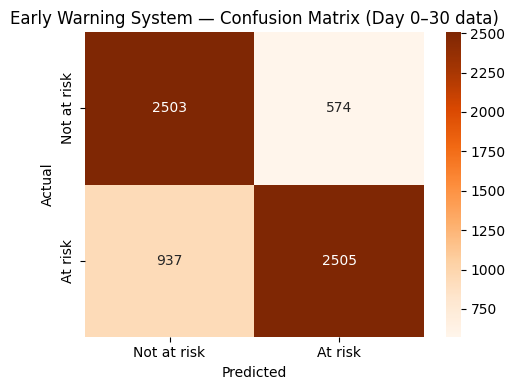


Saved: ./artifacts/early_warning_pipeline.joblib


In [6]:

# ═══════════════════════════════════════════════════════════════
#  EARLY WARNING SYSTEM — Predict at-risk students using only
#  data available in the FIRST 30 DAYS of the course.
#
#  Research motivation: Interventions must happen early.
#  A model that only works at the end of term is not actionable.
#  This cell builds an "early semester" feature set and measures
#  how accurately we can flag Fail/Withdrawn risk at day 30.
# ═══════════════════════════════════════════════════════════════

# ── Bootstrap: ensure all dependencies exist if run standalone ─
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants (safe to re-assign — same values as cell 1)
RANDOM_STATE = 42
DATA_DIR     = "../data/oulad"
ARTIFACT_DIR = "./artifacts"

# Load raw data only if prior cells haven't already run
if "student_vle" not in dir():
    print("  (Standalone run detected — loading raw data from disk...)")
    student_info       = pd.read_csv(os.path.join(DATA_DIR, "studentInfo.csv"))
    student_vle        = pd.read_csv(os.path.join(DATA_DIR, "studentVle.csv"))
    student_assessment = pd.read_csv(os.path.join(DATA_DIR, "studentAssessment.csv"))
    student_reg        = pd.read_csv(os.path.join(DATA_DIR, "studentRegistration.csv"))
    assessments        = pd.read_csv(os.path.join(DATA_DIR, "assessments.csv"))
    student_assessment["score"] = pd.to_numeric(student_assessment["score"], errors="coerce")
    print("  Raw data loaded.")

print("Building early-semester (day 0–30) features ...")

# ── Features available at day 30 ──────────────────────────────
# Demographic/registration features: always available
# VLE features: clicks and days active in first 30 days only
# Assessment features: any scores submitted within first 30 days

# Early VLE activity
early_vle_30 = (
    student_vle[student_vle["date"] <= 30]
    .groupby("id_student")
    .agg(
        early_total_clicks=("sum_click", "sum"),
        early_days_active=("date", "nunique"),
        early_max_daily_clicks=("sum_click", "max"),
        early_mean_daily_clicks=("sum_click", "mean"),
    )
    .reset_index()
)

# VLE resource diversity in first 30 days
vle_site_info_ew = pd.read_csv(os.path.join(DATA_DIR, "vle.csv"))
svle_early = (
    student_vle[student_vle["date"] <= 30]
    .merge(vle_site_info_ew[["id_site", "activity_type"]], on="id_site", how="left")
)
early_diversity = (
    svle_early.groupby("id_student")["activity_type"].nunique()
    .reset_index(name="early_activity_types")
)

# Early assessments: scores submitted by day 30
ass_w_ew = student_assessment.merge(
    assessments[["id_assessment", "weight", "assessment_type", "date"]],
    on="id_assessment", how="left"
)
ass_w_ew["score"] = pd.to_numeric(ass_w_ew["score"], errors="coerce")
ass_w_ew["date"]  = pd.to_numeric(ass_w_ew["date"],  errors="coerce")
early_assessments = (
    ass_w_ew[ass_w_ew["date"] <= 30]
    .groupby("id_student")
    .agg(
        early_mean_score=("score", "mean"),
        early_num_submitted=("id_assessment", "count"),
    )
    .reset_index()
    .fillna(0)
)

# Registration features (available from day 0)
reg_early = student_reg.copy()
reg_early["date_registration"] = pd.to_numeric(reg_early["date_registration"], errors="coerce")
reg_early["reg_before_start"] = -reg_early["date_registration"]
reg_early = reg_early.groupby("id_student").agg(
    first_reg_before_start_ew=("reg_before_start", "max"),
).reset_index()

# ── Build early-warning dataset ────────────────────────────────
data_ew = (
    student_info[["id_student", "gender", "region", "highest_education",
                  "imd_band", "age_band", "disability", "code_module",
                  "code_presentation", "num_of_prev_attempts",
                  "studied_credits", "final_result"]]
    .merge(early_vle_30,      on="id_student", how="left")
    .merge(early_diversity,   on="id_student", how="left")
    .merge(early_assessments, on="id_student", how="left")
    .merge(reg_early,         on="id_student", how="left")
)

ew_fill_cols = ["early_total_clicks", "early_days_active", "early_max_daily_clicks",
                "early_mean_daily_clicks", "early_activity_types",
                "early_mean_score", "early_num_submitted", "first_reg_before_start_ew"]
for col in ew_fill_cols:
    data_ew[col] = data_ew[col].fillna(0)

data_ew = data_ew.dropna(subset=["final_result"]).copy()

# Create binary at-risk target: Fail or Withdrawn = 1
data_ew["at_risk"] = data_ew["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

ew_cat_features = ["gender", "region", "highest_education", "imd_band",
                   "age_band", "disability", "code_module", "code_presentation"]
ew_num_features = ["num_of_prev_attempts", "studied_credits",
                   "early_total_clicks", "early_days_active",
                   "early_max_daily_clicks", "early_mean_daily_clicks",
                   "early_activity_types", "early_mean_score",
                   "early_num_submitted", "first_reg_before_start_ew"]

X_ew = data_ew[ew_cat_features + ew_num_features]
y_ew = data_ew["at_risk"]

X_ew_train, X_ew_test, y_ew_train, y_ew_test = train_test_split(
    X_ew, y_ew, test_size=0.2, stratify=y_ew, random_state=RANDOM_STATE
)

preprocess_ew = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ew_cat_features),
        ("num", StandardScaler(),                       ew_num_features),
    ]
)

# ── Train early-warning classifier ────────────────────────────
ew_pipeline = Pipeline([
    ("preprocess", preprocess_ew),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_ew_train == 0).sum() / (y_ew_train == 1).sum(),
        objective="binary:logistic",
        random_state=RANDOM_STATE,
    ))
])

t0 = time.time()
ew_pipeline.fit(X_ew_train, y_ew_train)
print(f"  Training time: {time.time()-t0:.1f}s")

y_ew_pred      = ew_pipeline.predict(X_ew_test)
y_ew_prob      = ew_pipeline.predict_proba(X_ew_test)[:, 1]
acc_ew         = accuracy_score(y_ew_test, y_ew_pred)

# ── At-risk detection coverage ─────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_ew_test, y_ew_pred).ravel()
recall_at_risk  = tp / (tp + fn)   # sensitivity: % of actual at-risk students caught
precision_alert = tp / (tp + fp)   # % of raised alerts that are correct

print(f"\n{'═'*60}")
print(f"  EARLY WARNING SYSTEM (Day 0–30 features only)")
print(f"{'═'*60}")
print(f"  Overall accuracy           : {acc_ew:.4f}")
print(f"  At-risk student recall     : {recall_at_risk:.4f}  (students correctly flagged)")
print(f"  Alert precision            : {precision_alert:.4f}  (alerts that are correct)")
print(f"  At-risk students missed    : {fn}  (false negatives)")
print(f"  False alarms raised        : {fp}  (false positives)")
print(f"{'─'*60}")

print("\nClassification Report (Not-at-risk vs At-risk):")
print(classification_report(y_ew_test, y_ew_pred,
                             target_names=["Not at risk", "At risk"]))

# ── Confusion matrix ───────────────────────────────────────────
cm_ew = confusion_matrix(y_ew_test, y_ew_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ew, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Not at risk", "At risk"],
            yticklabels=["Not at risk", "At risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Early Warning System — Confusion Matrix (Day 0–30 data)")
plt.tight_layout()
plt.show()

# Save
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(ew_pipeline, os.path.join(ARTIFACT_DIR, "early_warning_pipeline.joblib"))
print(f"\nSaved: {ARTIFACT_DIR}/early_warning_pipeline.joblib")


In [16]:

# ═══════════════════════════════════════════════════════════════
#  PERSONALIZED LEARNING PATH RECOMMENDATION ENGINE
#
#  Maps predicted learner profiles to specific, actionable
#  learning path recommendations.
#
#  Profile taxonomy (aligned with educational research):
#    1. High Achiever      → predicted: Distinction
#    2. Steady Progressor  → predicted: Pass
#    3. At-Risk Learner    → predicted: Fail
#    4. Disengaged Learner → predicted: Withdrawn
# ═══════════════════════════════════════════════════════════════

import os, json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# ── Bootstrap: define feature lists if prior cells haven't run ─
_globals = globals()

if "categorical_features" not in _globals:
    categorical_features = [
        "gender", "region", "highest_education", "imd_band",
        "age_band", "disability", "code_module", "code_presentation",
    ]

if "numeric_features" not in _globals:
    _behavior_cols = [
        "total_clicks", "days_active", "max_daily_clicks",
        "mean_daily_clicks", "early_clicks", "mean_score",
        "num_assessments", "first_reg_before_start", "ever_unregistered",
    ]
    numeric_features = _behavior_cols + ["num_of_prev_attempts", "studied_credits"]

if "new_numeric_feats" not in _globals:
    new_numeric_feats = [
        "score_std", "score_min", "score_max",
        "weighted_mean_score", "score_trend",
        "tma_mean_score", "cma_mean_score", "exam_score", "has_exam_score",
        "click_ratio_early", "click_ratio_mid", "click_ratio_late",
        "distinct_activity_types", "social_clicks", "resource_clicks", "quiz_clicks",
    ]

if "ARTIFACT_DIR" not in _globals:
    ARTIFACT_DIR = "./artifacts"

# ── Recommendation knowledge base ─────────────────────────────
LEARNING_PATH_RECOMMENDATIONS = {
    "Distinction": {
        "profile":       "High Achiever",
        "description":   "Consistently strong performer with high engagement and excellent assessment results.",
        "learning_path": "Advanced Track",
        "actions": [
            "Unlock advanced/extension modules and challenge problems",
            "Recommend peer mentoring or study group leadership roles",
            "Suggest research projects or external certifications",
            "Provide early access to next-level course materials",
            "Offer enrichment seminars and guest lecture invitations",
        ],
        "alert_level":   "None",
        "intervention":  "Enrichment",
    },
    "Pass": {
        "profile":       "Steady Progressor",
        "description":   "On track for successful completion. Consistent but may benefit from additional challenge.",
        "learning_path": "Standard Track",
        "actions": [
            "Follow the standard course pathway with scheduled checkpoints",
            "Encourage optional extension exercises to improve grade",
            "Suggest study skills workshops to unlock higher performance",
            "Pair with a High Achiever peer mentor when available",
            "Set fortnightly self-assessment goals",
        ],
        "alert_level":   "Low",
        "intervention":  "Encouragement",
    },
    "Fail": {
        "profile":       "At-Risk Learner",
        "description":   "Academic performance signals risk of failing. Targeted support required.",
        "learning_path": "Supported Track",
        "actions": [
            "Trigger immediate personal tutor meeting request",
            "Enrol in supplementary tutorial sessions or drop-in sessions",
            "Assign structured study plan with weekly milestones",
            "Provide formative feedback on all upcoming assessments",
            "Flag to student support services for academic counselling",
            "Recommend time management and exam preparation resources",
        ],
        "alert_level":   "High",
        "intervention":  "Academic Support",
    },
    "Withdrawn": {
        "profile":       "Disengaged Learner",
        "description":   "Low LMS engagement and academic participation. High withdrawal risk.",
        "learning_path": "Re-engagement Track",
        "actions": [
            "Initiate welfare check — contact student directly within 48 hours",
            "Assign a dedicated personal tutor / advisor for regular contact",
            "Offer flexible study options (recorded lectures, async materials)",
            "Identify and address barriers (financial, health, personal)",
            "Set minimum weekly engagement targets with progress nudges",
            "Escalate to student retention office if no contact within 5 days",
        ],
        "alert_level":   "Critical",
        "intervention":  "Retention & Welfare",
    },
}

def get_learning_path_recommendation(predicted_outcome: str) -> dict:
    """Return the full recommendation record for a predicted outcome."""
    return LEARNING_PATH_RECOMMENDATIONS.get(predicted_outcome, {})


def print_recommendation(student_id, predicted_outcome: str, confidence: float = None):
    """Print a formatted recommendation card for a student."""
    rec = get_learning_path_recommendation(predicted_outcome)
    if not rec:
        print(f"No recommendation for outcome: {predicted_outcome}")
        return

    alert_colors = {"None": "✅", "Low": "🟡", "High": "🔴", "Critical": "🚨"}
    icon = alert_colors.get(rec["alert_level"], "ℹ️")

    print(f"\n{'═'*62}")
    print(f"  Student ID : {student_id}")
    if confidence is not None:
        print(f"  Confidence : {confidence:.1%}")
    print(f"  Profile    : {rec['profile']}")
    print(f"  Outcome    : {predicted_outcome}  {icon} Alert: {rec['alert_level']}")
    print(f"  Path       : {rec['learning_path']}")
    print(f"{'─'*62}")
    print(f"  {rec['description']}")
    print(f"\n  Recommended Actions ({rec['intervention']}):")
    for i, action in enumerate(rec["actions"], 1):
        print(f"    {i}. {action}")
    print(f"{'═'*62}")


# Decode label robustly: LightGBM returns strings, XGBoost returns integer codes
_OUTCOME_CLASSES = sorted(["Distinction", "Fail", "Pass", "Withdrawn"])

def decode_label(label):
    if isinstance(label, (int, np.integer)):
        return _OUTCOME_CLASSES[label]
    return str(label)


# ── Demonstrate on representative students ────────────────────
print("=" * 62)
print("  PERSONALIZED LEARNING PATH RECOMMENDER — Demo")
print("=" * 62)

# Load the best trained pipeline
best_pipeline_loaded = joblib.load(os.path.join(ARTIFACT_DIR, "best_model_pipeline.joblib"))

# Representative student profiles for demonstration
demo_students = pd.DataFrame([
    {   # High engager — likely Distinction
        "id": "S001",
        "gender": "F", "region": "South Region", "highest_education": "HE Qualification",
        "imd_band": "80-90", "age_band": "26-35", "disability": "N",
        "code_module": "BBB", "code_presentation": "2014J",
        "num_of_prev_attempts": 0, "studied_credits": 120,
        "total_clicks": 2800, "days_active": 90, "max_daily_clicks": 120,
        "mean_daily_clicks": 31, "early_clicks": 600, "mean_score": 88,
        "num_assessments": 7, "first_reg_before_start": 60, "ever_unregistered": 0,
        "score_std": 5, "score_min": 80, "score_max": 95,
        "weighted_mean_score": 87, "score_trend": 0.5,
        "tma_mean_score": 86, "cma_mean_score": 88, "exam_score": 90,
        "has_exam_score": 1, "click_ratio_early": 0.21, "click_ratio_mid": 0.45,
        "click_ratio_late": 0.34, "distinct_activity_types": 12,
        "social_clicks": 150, "resource_clicks": 900, "quiz_clicks": 200,
    },
    {   # Average engager — likely Pass
        "id": "S002",
        "gender": "M", "region": "East Anglian Region", "highest_education": "A Level or Equivalent",
        "imd_band": "40-50", "age_band": "18-25", "disability": "N",
        "code_module": "AAA", "code_presentation": "2013B",
        "num_of_prev_attempts": 0, "studied_credits": 60,
        "total_clicks": 900, "days_active": 45, "max_daily_clicks": 50,
        "mean_daily_clicks": 20, "early_clicks": 200, "mean_score": 62,
        "num_assessments": 5, "first_reg_before_start": 20, "ever_unregistered": 0,
        "score_std": 8, "score_min": 50, "score_max": 74,
        "weighted_mean_score": 62, "score_trend": 0.1,
        "tma_mean_score": 63, "cma_mean_score": 60, "exam_score": 61,
        "has_exam_score": 1, "click_ratio_early": 0.22, "click_ratio_mid": 0.40,
        "click_ratio_late": 0.38, "distinct_activity_types": 7,
        "social_clicks": 40, "resource_clicks": 320, "quiz_clicks": 60,
    },
    {   # Low engager, low scores — likely Fail
        "id": "S003",
        "gender": "M", "region": "North Region", "highest_education": "Lower Than A Level",
        "imd_band": "10-20", "age_band": "18-25", "disability": "N",
        "code_module": "CCC", "code_presentation": "2014B",
        "num_of_prev_attempts": 2, "studied_credits": 60,
        "total_clicks": 300, "days_active": 18, "max_daily_clicks": 30,
        "mean_daily_clicks": 8, "early_clicks": 40, "mean_score": 38,
        "num_assessments": 3, "first_reg_before_start": 5, "ever_unregistered": 0,
        "score_std": 12, "score_min": 20, "score_max": 55,
        "weighted_mean_score": 36, "score_trend": -0.8,
        "tma_mean_score": 38, "cma_mean_score": 34, "exam_score": 0,
        "has_exam_score": 0, "click_ratio_early": 0.13, "click_ratio_mid": 0.55,
        "click_ratio_late": 0.32, "distinct_activity_types": 4,
        "social_clicks": 10, "resource_clicks": 80, "quiz_clicks": 15,
    },
    {   # Virtually no engagement — likely Withdrawn
        "id": "S004",
        "gender": "M", "region": "West Midlands Region", "highest_education": "No Formal quals",
        "imd_band": "0-10", "age_band": "18-25", "disability": "N",
        "code_module": "DDD", "code_presentation": "2013J",
        "num_of_prev_attempts": 1, "studied_credits": 60,
        "total_clicks": 50, "days_active": 5, "max_daily_clicks": 20,
        "mean_daily_clicks": 3, "early_clicks": 10, "mean_score": 0,
        "num_assessments": 0, "first_reg_before_start": 2, "ever_unregistered": 1,
        "score_std": 0, "score_min": 0, "score_max": 0,
        "weighted_mean_score": 0, "score_trend": 0,
        "tma_mean_score": 0, "cma_mean_score": 0, "exam_score": 0,
        "has_exam_score": 0, "click_ratio_early": 0.20, "click_ratio_mid": 0.60,
        "click_ratio_late": 0.20, "distinct_activity_types": 2,
        "social_clicks": 0, "resource_clicks": 10, "quiz_clicks": 0,
    },
])

# Determine feature columns (same as best_model_pipeline expects)
numeric_features_ext = numeric_features + new_numeric_feats
demo_feature_cols = categorical_features + numeric_features_ext

# Fill any missing feature columns with 0
for col in demo_feature_cols:
    if col not in demo_students.columns:
        demo_students[col] = 0

X_demo = demo_students[demo_feature_cols]

probs_demo    = best_pipeline_loaded.predict_proba(X_demo)
pred_demo_raw = best_pipeline_loaded.predict(X_demo)

for idx, row in demo_students.iterrows():
    pred_label = decode_label(pred_demo_raw[idx])
    confidence = probs_demo[idx].max()
    print_recommendation(row["id"], pred_label, confidence)

# Save the recommendation lookup
rec_path = os.path.join(ARTIFACT_DIR, "learning_path_recommendations.json")
with open(rec_path, "w") as f:
    json.dump(LEARNING_PATH_RECOMMENDATIONS, f, indent=2)
print(f"\nRecommendation knowledge base saved -> {rec_path}")


  PERSONALIZED LEARNING PATH RECOMMENDER — Demo

══════════════════════════════════════════════════════════════
  Student ID : S001
  Confidence : 55.0%
  Profile    : Steady Progressor
  Outcome    : Pass  🟡 Alert: Low
  Path       : Standard Track
──────────────────────────────────────────────────────────────
  On track for successful completion. Consistent but may benefit from additional challenge.

  Recommended Actions (Encouragement):
    1. Follow the standard course pathway with scheduled checkpoints
    2. Encourage optional extension exercises to improve grade
    3. Suggest study skills workshops to unlock higher performance
    4. Pair with a High Achiever peer mentor when available
    5. Set fortnightly self-assessment goals
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Student ID : S002
  Confidence : 85.9%
  Profile    : Steady Progressor
  Outcome    : Pass  🟡 Alert: Low
  Path       : S

In [17]:

# ═══════════════════════════════════════════════════════════════
#  INTEGRATED INFERENCE PIPELINE
#  Simulates the full production flow for a new student:
#    Step 1 → Early warning check (day 0–30 data only)
#    Step 2 → Full profile prediction (end-of-term features)
#    Step 3 → Learning path recommendation output
#
#  This is the interface your recommender system would call.
# ═══════════════════════════════════════════════════════════════

import json

def classify_and_recommend(
    student_id: str,
    early_features: dict,       # features available at day 30
    full_features: dict = None  # full-semester features (optional)
) -> dict:
    """
    Full inference pipeline.

    Parameters
    ----------
    student_id    : identifier for display
    early_features: dict of day-0-to-30 features (EW model input)
    full_features : dict of all features (best model input). If None,
                    only early-warning output is returned.

    Returns dict with keys:
        early_at_risk, early_risk_prob, predicted_outcome,
        confidence, profile, learning_path, actions, alert_level
    """
    result = {"student_id": student_id}

    # ── Early warning ─────────────────────────────────────────
    ew_cols = ew_cat_features + ew_num_features
    X_early = pd.DataFrame([{c: early_features.get(c, 0) for c in ew_cols}])
    ew_prob  = ew_pipeline.predict_proba(X_early)[0][1]
    ew_flag  = int(ew_prob >= 0.5)

    result["early_at_risk"]     = bool(ew_flag)
    result["early_risk_prob"]   = round(float(ew_prob), 4)

    # ── Full prediction (if semester-end features available) ──
    if full_features is not None:
        feat_cols_full = categorical_features + numeric_features_ext
        X_full = pd.DataFrame([{c: full_features.get(c, 0) for c in feat_cols_full}])
        prob_full   = best_pipeline_loaded.predict_proba(X_full)[0]
        pred_enc    = best_pipeline_loaded.predict(X_full)[0]
        pred_label  = decode_label(pred_enc)
        confidence  = float(prob_full.max())

        rec = get_learning_path_recommendation(pred_label)
        result.update({
            "predicted_outcome": pred_label,
            "confidence":        round(confidence, 4),
            "profile":           rec.get("profile"),
            "learning_path":     rec.get("learning_path"),
            "actions":           rec.get("actions"),
            "alert_level":       rec.get("alert_level"),
        })
    else:
        # Derive rough recommendation from early warning alone
        outcome_guess = "Withdrawn" if ew_prob >= 0.75 else ("Fail" if ew_flag else "Pass")
        rec = get_learning_path_recommendation(outcome_guess)
        result.update({
            "predicted_outcome": f"{outcome_guess} (early estimate)",
            "confidence":        round(float(1 - abs(ew_prob - 0.5) * 2), 4),
            "profile":           rec.get("profile"),
            "learning_path":     rec.get("learning_path"),
            "actions":           rec.get("actions"),
            "alert_level":       rec.get("alert_level"),
        })

    return result


def print_full_report(result: dict):
    """Pretty-print the full inference result."""
    alert_icons = {"None": "✅", "Low": "🟡", "High": "🔴", "Critical": "🚨"}
    icon = alert_icons.get(result.get("alert_level", "None"), "ℹ️")

    print(f"\n{'═'*65}")
    print(f"  LEARNER PROFILE REPORT — Student {result['student_id']}")
    print(f"{'─'*65}")
    print(f"  Early Warning (day 0–30) : {'AT RISK' if result['early_at_risk'] else 'On Track'}"
          f"  (risk prob: {result['early_risk_prob']:.1%})")
    print(f"  Predicted Outcome        : {result['predicted_outcome']}")
    print(f"  Prediction Confidence    : {result['confidence']:.1%}")
    print(f"  Learner Profile          : {result['profile']}")
    print(f"  Assigned Learning Path   : {result['learning_path']}")
    print(f"  Alert Level              : {result.get('alert_level')} {icon}")
    print(f"{'─'*65}")
    print(f"  Recommended Actions:")
    for i, action in enumerate(result.get("actions", []), 1):
        print(f"    {i}. {action}")
    print(f"{'═'*65}")


# ── Example: New student with only early-semester data ─────────
print("SCENARIO 1: Student with early-semester (day 0–30) data only\n")

new_student_early = {
    "gender": "M", "region": "North Western Region",
    "highest_education": "Lower Than A Level",
    "imd_band": "10-20", "age_band": "18-25",
    "disability": "N", "code_module": "BBB", "code_presentation": "2014J",
    "num_of_prev_attempts": 1, "studied_credits": 60,
    "early_total_clicks": 95,
    "early_days_active": 8,
    "early_max_daily_clicks": 25,
    "early_mean_daily_clicks": 12,
    "early_activity_types": 3,
    "early_mean_score": 0,         # no assessments submitted yet
    "early_num_submitted": 0,
    "first_reg_before_start_ew": 3,
}

result_early = classify_and_recommend(
    student_id="NEW-001",
    early_features=new_student_early,
)
print_full_report(result_early)

# ── Example: Student with full-semester data ────────────────────
print("\nSCENARIO 2: Student with full-semester data\n")

new_student_full_early = new_student_early.copy()
new_student_full_features = {
    "gender": "M", "region": "North Western Region",
    "highest_education": "Lower Than A Level",
    "imd_band": "10-20", "age_band": "18-25",
    "disability": "N", "code_module": "BBB", "code_presentation": "2014J",
    "num_of_prev_attempts": 1, "studied_credits": 60,
    # base numeric
    "total_clicks": 310, "days_active": 19, "max_daily_clicks": 30,
    "mean_daily_clicks": 9, "early_clicks": 95, "mean_score": 41,
    "num_assessments": 3, "first_reg_before_start": 3, "ever_unregistered": 0,
    # enhanced numeric
    "score_std": 10, "score_min": 28, "score_max": 55,
    "weighted_mean_score": 40, "score_trend": -0.3,
    "tma_mean_score": 41, "cma_mean_score": 38, "exam_score": 0,
    "has_exam_score": 0,
    "click_ratio_early": 0.31, "click_ratio_mid": 0.52, "click_ratio_late": 0.17,
    "distinct_activity_types": 5, "social_clicks": 8,
    "resource_clicks": 100, "quiz_clicks": 20,
}

result_full = classify_and_recommend(
    student_id="NEW-001",
    early_features=new_student_full_early,
    full_features=new_student_full_features,
)
print_full_report(result_full)

# Save the full inference function
print("\nAll artifacts saved to ./artifacts/")
print("  - best_model_pipeline.joblib")
print("  - early_warning_pipeline.joblib")
print("  - learning_path_recommendations.json")


SCENARIO 1: Student with early-semester (day 0–30) data only


═════════════════════════════════════════════════════════════════
  LEARNER PROFILE REPORT — Student NEW-001
─────────────────────────────────────────────────────────────────
  Early Warning (day 0–30) : AT RISK  (risk prob: 90.5%)
  Predicted Outcome        : Withdrawn (early estimate)
  Prediction Confidence    : 19.0%
  Learner Profile          : Disengaged Learner
  Assigned Learning Path   : Re-engagement Track
  Alert Level              : Critical 🚨
─────────────────────────────────────────────────────────────────
  Recommended Actions:
    1. Initiate welfare check — contact student directly within 48 hours
    2. Assign a dedicated personal tutor / advisor for regular contact
    3. Offer flexible study options (recorded lectures, async materials)
    4. Identify and address barriers (financial, health, personal)
    5. Set minimum weekly engagement targets with progress nudges
    6. Escalate to student retention o